# Mirza_VIIRS_Plots
## Final Suomi-NPP VIIRS Level-1B workflow

This notebook presents a complete, reproducible workflow for two Suomi-NPP VIIRS case studies:

- **Scene 1:** 7 June 2023 — Northeastern U.S. wildfire-smoke case
- **Scene 2:** 28 September 2022 — Hurricane Ian over Florida

I use matched **VNP02MOD Level-1B observation** and **VNP03MOD geolocation** granules to download, calibrate, inspect, map, export, and compare VIIRS M-band measurements.

### Assignment products generated
**Part (a):** four true-color figures — native and projected views for both scenes  
**Part (b):** acquisition date/time and principal scene feature  
**Part (c):** binary radiance files for M03, M04, M05, M15, and M16 for both scenes  
**Part (d):** clear-land vs cloud spectral comparison for Scene 1  
**Part (e):** M01–M16 radiance comparison for the same two Scene 1 pixels

### Data and grid size used in this notebook
For the selected granules, each native VIIRS M-band array is **3232 rows × 3200 columns**, or **10,342,400 samples per band**. A single `float32` array of that size is approximately **39.45 MiB** before filesystem overhead.

The projected maps use an output grid spacing of **0.0075° × 0.0075°**. This is the **resampling-grid cell size**, not a claim that projection creates new sensor resolution.

### Figure sizing
Native full-swath figures use a fixed **10.2 × 8.2 inch** canvas for consistency. Projected geographic maps follow the AOI aspect ratio so the Northeast scene is naturally wider while the Florida scene is more vertically oriented. Detailed selected-pixel and spectral figures use larger canvases where needed for legibility.

### Scientific processing choices
Reflective solar bands and thermal emissive bands are calibrated using the attributes stored in the VIIRS product. True color uses **M05/M04/M03 = red/green/blue**. Native RGB receives display-only small-gap filling; the calibrated scientific arrays remain unchanged. Projected RGB uses scan-aware EWA resampling where available. M06 values at the final Scene 1 reference pixels are QA-flagged as `Out_of_Range`, so M06 is retained in the documented band sequence but masked from scientific interpretation.

> **Run order:** execute **Code Cell 01 → Code Cell 22** from top to bottom. The explicit cell labels below remain stable even if Colab changes its own execution counters.

> **Security note:** I do not hard-code my NASA Earthdata/LAADS token in this notebook.


## Code-cell execution map

| Code cell | Purpose |
|---:|---|
| **01** | Install/import packages |
| **02** | Authenticate with NASA LAADS DAAC |
| **03** | Define scenes and output settings |
| **04** | Define LAADS search/download helpers |
| **05** | Download matched VNP02MOD/VNP03MOD scene pairs |
| **06** | Inspect the Level-1B file structure |
| **07** | Define M-band metadata and calibration readers |
| **08** | Read both scenes and validate required radiance arrays |
| **09** | Construct display-only VIIRS true-color RGB |
| **10** | Define mapping, projection, and figure helpers |
| **11** | Generate the four required Part (a) figures |
| **12** | Build Part (b) acquisition-time/feature table |
| **13** | Export Part (c) binary radiance files |
| **14** | Fix Scene 1 reference pixels and inspect M06 QA |
| **15** | Prepare QA-masked M01–M11 reflectance spectra |
| **16** | Plot selected pixels on the projected map |
| **17** | Plot selected pixels in native swath geometry |
| **18** | Create the three-panel land/cloud spectral comparison |
| **19** | Create the Part (e) M01–M16 radiance comparison |
| **20** | Export Scene 1 spectral values to CSV |
| **21** | Audit all expected outputs |
| **22** | Package final outputs into a submission ZIP |

The notebook is intentionally organized so that every later cell depends only on cells above it.


**Code Cell 01 — Environment setup**

## 1. Environment setup

**Now I will install and import the Python packages needed for the complete workflow.** These libraries handle NetCDF access, NASA downloads, VIIRS calibration, geolocation, resampling, mapping, plotting, tabular output, and binary export.

Expected result: the runtime has all required packages and the output directories can be created later without dependency errors.


In [ ]:
# CODE CELL 01 — ENVIRONMENT SETUP
!pip -q install netCDF4 pyresample cartopy beautifulsoup4 requests pandas scipy "dask[array]" xarray

import os
import re
import json
import warnings
import shutil
import zipfile
from pathlib import Path
from urllib.parse import urljoin
from getpass import getpass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import requests
from bs4 import BeautifulSoup
from netCDF4 import Dataset

from scipy.ndimage import uniform_filter

from pyresample import geometry, kd_tree
from pyresample.ewa import DaskEWAResampler

import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Keep the notebook readable without hiding potentially important scientific warnings.
warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 700,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "figure.titlesize": 14,
})

print("Environment ready.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 153.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 135.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 161.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 464.5/464.5 kB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 94.4 MB/s eta 0:00:00
Environment ready.


**Code Cell 02 — NASA LAADS DAAC authentication**

## 2. NASA LAADS DAAC authentication

**Now I will authenticate with NASA LAADS DAAC.** I enter my bearer token interactively so the credential remains in memory rather than being written into the notebook.

Expected result: `LAADS_TOKEN` contains a non-empty token for the download requests.


In [ ]:
# CODE CELL 02 — NASA LAADS DAAC AUTHENTICATION
LAADS_TOKEN = getpass("Paste your NASA LAADS DAAC bearer token: ").strip()
if len(LAADS_TOKEN) < 20:
    raise ValueError("Token appears invalid or too short.")

LAADS_HEADERS = {
    "Authorization": f"Bearer {LAADS_TOKEN}",
    "X-Requested-With": "XMLHttpRequest",
    "User-Agent": "VIIRS-L1B-Colab-Homework/1.0",
}
print("Token loaded for this runtime.")

Paste your NASA LAADS DAAC bearer token: ··········
Token loaded for this runtime.


**Code Cell 03 — Scene configuration and output settings**

## 3. Scene configuration and output settings

**Now I will define the two case-study scenes, their acquisition windows, preferred granules, map extents, output folders, figure resolution, and projected-grid cell size.**

The bounding-box order is `(west, south, east, north)`. I use `GRID_RES_DEG = 0.0075`, so each projected raster cell is **0.0075° × 0.0075°**. The saved figures use **700 dpi**.

The Northeast and Florida projected figures are intentionally allowed to have different aspect ratios because their geographic AOIs have different shapes.


In [ ]:
# CODE CELL 03 — SCENE CONFIGURATION AND OUTPUT SETTINGS
SCENES = [
    {
        "id": "scene1",
        "label": "Northeastern U.S. — wildfire smoke case",
        "date": "2023-06-07",
        "start_utc": "16:00",
        "end_utc": "20:30",
        "preferred_key": "A2023158.1854",
        "bbox": (-76.4, 39.1, -72.40, 41.25),
        "feature_note": (
            "Widespread smoke/haze over the Mid-Atlantic and northeastern U.S. "
            "coastal region, with land-water and cloud contrasts visible."
        ),
    },
    {
        "id": "scene2",
        "label": "Florida — Hurricane Ian case",
        "date": "2022-09-28",
        "start_utc": "16:00",
        "end_utc": "21:00",
        "preferred_key": "A2022271.1918",
        "bbox": (-84.5, 24.5, -79.0, 30.5),
        "feature_note": (
            "Hurricane Ian's dense cloud shield and spiral circulation over Florida "
            "and adjacent Gulf/Atlantic waters on landfall day."
        ),
    },
]

RADIANCE_PRODUCT = "VNP02MOD"
GEO_PRODUCT = "VNP03MOD"

ROOT = Path("/content/Mirza_VIIRS_Plots_outputs")
DATA_DIR = ROOT / "data"
OUTPUT_DIR = ROOT / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
BINARY_DIR = OUTPUT_DIR / "binary"

for d in [DATA_DIR, OUTPUT_DIR, FIG_DIR, BINARY_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SAVE_DPI = 700
GRID_RES_DEG = 0.0075

pd.DataFrame(SCENES)

,id,label,date,start_utc,end_utc,preferred_key,bbox,feature_note
0,scene1,Northeastern U.S. — wildfire smoke case,2023-06-07,16:00,20:30,A2023158.1854,"(-76.4, 39.1, -72.4, 41.25)",Widespread smoke/haze over the Mid-Atlantic an...
1,scene2,Florida — Hurricane Ian case,2022-09-28,16:00,21:00,A2022271.1918,"(-84.5, 24.5, -79.0, 30.5)",Hurricane Ian's dense cloud shield and spiral ...


**Code Cell 04 — LAADS archive search/download helpers**

## 4. Find and download matched VNP02MOD / VNP03MOD granules

### 4.1 Define the LAADS search and download helpers

**Now I will build the helper functions that search the official LAADS archive, identify the requested acquisition key, pair VNP02MOD observations with the matching VNP03MOD geolocation granule, and download files only when needed.**

This separates the web/file-management logic from the scientific processing that follows.


In [ ]:
# CODE CELL 04 — LAADS ARCHIVE SEARCH/DOWNLOAD HELPERS
LAADS_BASE = "https://ladsweb.modaps.eosdis.nasa.gov"
ARCHIVE_SEARCH = f"{LAADS_BASE}/api/v2/content/archives"

def scene_temporal_range(scene):
    return f"{scene['date']} {scene['start_utc']}..{scene['date']} {scene['end_utc']}"

def bbox_to_region(bbox):
    w, s, e, n = bbox
    return f"[BBOX]W{w} S{s} E{e} N{n}"

def search_laads(product, scene, timeout=120):
    params = {
        "products": product,
        "temporalRanges": scene_temporal_range(scene),
        "regions": bbox_to_region(scene["bbox"]),
    }
    r = requests.get(ARCHIVE_SEARCH, params=params, headers=LAADS_HEADERS, timeout=timeout)
    r.raise_for_status()

    soup = BeautifulSoup(r.text, "html.parser")
    urls = []
    for a in soup.find_all("a", href=True):
        href = a["href"]
        if ".nc" in href:
            u = urljoin(r.url, href)
            if u.endswith(".nc"):
                urls.append(u)

    if not urls:
        found = re.findall(r'href=["\']([^"\']+\.nc)["\']', r.text, flags=re.I)
        urls = [urljoin(r.url, x) for x in found]

    return sorted(set(urls))

def basename(url):
    return url.split("?")[0].split("/")[-1]

def acquisition_key(name):
    m = re.search(r"(A\d{7}\.\d{4})", name)
    return m.group(1) if m else None

def pair_granules(rad_urls, geo_urls):
    rad = {acquisition_key(basename(u)): u for u in rad_urls}
    geo = {acquisition_key(basename(u)): u for u in geo_urls}
    common = sorted(set(rad) & set(geo))
    return [{
        "key": k,
        "radiance_url": rad[k],
        "geolocation_url": geo[k],
        "radiance_name": basename(rad[k]),
        "geolocation_name": basename(geo[k]),
    } for k in common]

def hm_to_minutes(hm):
    h, m = map(int, hm.split(":"))
    return 60*h + m


def choose_pair(pairs, scene):
    if not pairs:
        raise RuntimeError(
            f"No matched {RADIANCE_PRODUCT}/{GEO_PRODUCT} files found for {scene['id']}. "
            "Broaden the time window or bounding box."
        )

    preferred = scene.get("preferred_key")
    if preferred:
        for p in pairs:
            if p["key"] == preferred:
                return p

    target = (hm_to_minutes(scene["start_utc"]) + hm_to_minutes(scene["end_utc"])) / 2

    def score(p):
        hhmm = p["key"].split(".")[1]
        t = int(hhmm[:2]) * 60 + int(hhmm[2:])
        return abs(t - target)

    return min(pairs, key=score)

def download_file(url, out_dir, chunk_size=1024*1024):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    path = out_dir / basename(url)

    if path.exists() and path.stat().st_size > 100_000:
        print("Using existing:", path.name)
        return path

    print("Downloading:", path.name)
    with requests.get(url, headers=LAADS_HEADERS, stream=True, timeout=300) as r:
        r.raise_for_status()
        with open(path, "wb") as f:
            for chunk in r.iter_content(chunk_size=chunk_size):
                if chunk:
                    f.write(chunk)
    print("Saved:", path)
    return path

**Code Cell 05 — Download matched VNP02MOD/VNP03MOD scene pairs**

### 4.2 Download the two matched scene pairs

**Now I will execute the search for both scenes and download the matched radiance and geolocation files.** The code records the exact filenames so the analysis remains traceable to the source granules.

Expected result: two VNP02MOD files and two VNP03MOD files are available in the data directory.


In [ ]:
# CODE CELL 05 — DOWNLOAD MATCHED VNP02MOD/VNP03MOD SCENE PAIRS
scene_files = {}

for scene in SCENES:
    print("="*90)
    print(scene["id"], "|", scene["label"])

    rad_urls = search_laads(RADIANCE_PRODUCT, scene)
    geo_urls = search_laads(GEO_PRODUCT, scene)

    print("Radiance files found:", len(rad_urls))
    print("Geolocation files found:", len(geo_urls))

    pairs = pair_granules(rad_urls, geo_urls)
    print("Matched acquisitions:", len(pairs))

    if pairs:
        display(pd.DataFrame(pairs)[["key","radiance_name","geolocation_name"]])

    selected = choose_pair(pairs, scene)
    print("Selected acquisition:", selected["key"])

    sdir = DATA_DIR / scene["id"]
    rpath = download_file(selected["radiance_url"], sdir)
    gpath = download_file(selected["geolocation_url"], sdir)

    scene_files[scene["id"]] = {
        **selected,
        "radiance_path": rpath,
        "geolocation_path": gpath,
    }

print("All scene files are ready.")

scene1 | Northeastern U.S. — wildfire smoke case
Radiance files found: 4
Geolocation files found: 4
Matched acquisitions: 4


,key,radiance_name,geolocation_name
0,A2023158.1712,VNP02MOD.A2023158.1712.002.2023159003854.nc,VNP03MOD.A2023158.1712.002.2023159002016.nc
1,A2023158.1718,VNP02MOD.A2023158.1718.002.2023159003909.nc,VNP03MOD.A2023158.1718.002.2023159002008.nc
2,A2023158.1854,VNP02MOD.A2023158.1854.002.2023159022132.nc,VNP03MOD.A2023158.1854.002.2023159020243.nc
3,A2023158.1900,VNP02MOD.A2023158.1900.002.2023159022122.nc,VNP03MOD.A2023158.1900.002.2023159020245.nc


Selected acquisition: A2023158.1854
Downloading: VNP02MOD.A2023158.1854.002.2023159022132.nc
Saved: /content/Mirza_VIIRS_Plots_outputs/data/scene1/VNP02MOD.A2023158.1854.002.2023159022132.nc
Downloading: VNP03MOD.A2023158.1854.002.2023159020243.nc
Saved: /content/Mirza_VIIRS_Plots_outputs/data/scene1/VNP03MOD.A2023158.1854.002.2023159020243.nc
scene2 | Florida — Hurricane Ian case
Radiance files found: 2
Geolocation files found: 2
Matched acquisitions: 2


,key,radiance_name,geolocation_name
0,A2022271.1736,VNP02MOD.A2022271.1736.002.2022272014307.nc,VNP03MOD.A2022271.1736.002.2022272012440.nc
1,A2022271.1918,VNP02MOD.A2022271.1918.002.2022272033155.nc,VNP03MOD.A2022271.1918.002.2022272030743.nc


Selected acquisition: A2022271.1918
Downloading: VNP02MOD.A2022271.1918.002.2022272033155.nc
Saved: /content/Mirza_VIIRS_Plots_outputs/data/scene2/VNP02MOD.A2022271.1918.002.2022272033155.nc
Downloading: VNP03MOD.A2022271.1918.002.2022272030743.nc
Saved: /content/Mirza_VIIRS_Plots_outputs/data/scene2/VNP03MOD.A2022271.1918.002.2022272030743.nc
All scene files are ready.


**Code Cell 06 — Inspect the Level-1B file structure**

## 5. Inspect the Level-1B file structure

**Now I will inspect the first Level-1B granule before extracting science variables.** This follows the course workflow of checking groups, dimensions, variable names, and attributes before processing the data.

This diagnostic step helps verify that I am reading the intended VIIRS product structure rather than assuming variable names or calibration metadata.


In [ ]:
# CODE CELL 06 — INSPECT THE LEVEL-1B FILE STRUCTURE
first_rad = scene_files["scene1"]["radiance_path"]

with Dataset(first_rad) as ds:
    print("GLOBAL ATTRIBUTES")
    for a in ds.ncattrs():
        print(" ", a, "=", getattr(ds, a))

    print("\nGROUPS / VARIABLES")
    for gname, grp in ds.groups.items():
        print("\nGROUP:", gname)
        for vname, var in grp.variables.items():
            print(f"  {vname:38s} shape={str(var.shape):18s} dtype={var.dtype}")

GLOBAL ATTRIBUTES
  date_created = 2023-06-07T22:21:59Z
  ProductionTime = 2023-06-07T22:21:59Z
  title = VIIRS M-band Reflected Solar Band and Thermal Emissive Band Data
  ShortName = VNP02MOD
  LongName = VIIRS/NPP Moderate Resolution 6-Min L1B Swath 750m
  instrument = VIIRS
  processing_version = v3.0.0
  Conventions = CF-1.6
  institution = NASA Goddard Space Flight Center, VIIRS L1 Processing Group
  license = http://science.nasa.gov/earth-science/earth-science-data/data-information-policy/
  naming_authority = gov.nasa.gsfc.VIIRSland
  keywords_vocabulary = NASA Global Change Master Directory (GCMD) Science Keywords
  standard_name_vocabulary = 
  creator_name = VIIRS L1 Processing Group
  creator_email = modis-ops@lists.nasa.gov
  creator_url = https://ladsweb.modaps.eosdis.nasa.gov
  project = VIIRS L1 Project
  publisher_name = LAADS
  publisher_url = https://ladsweb.modaps.eosdis.nasa.gov
  publisher_email = modis-ops@lists.nasa.gov
  processing_level = L1B
  cdm_data_type =

**Code Cell 07 — M-band metadata and calibration readers**

## 6. Define M-band wavelengths and calibrate VIIRS measurements

**Now I will define the M01–M16 wavelength metadata and the calibration reader used throughout the notebook.**

For M01–M11, I reconstruct radiance and solar reflectance from the product calibration attributes. For M12–M16, I reconstruct thermal radiance and use the VIIRS brightness-temperature lookup information. Invalid scaled integers are masked using each variable's own valid range, which is important for M13 because its stored integer range differs from the other M-bands.

This cell creates reusable functions; it does not yet select land/cloud pixels or generate final figures.


In [ ]:
# CODE CELL 07 — M-BAND METADATA AND CALIBRATION READERS
BAND_CENTERS_UM = {
    "M01":0.415, "M02":0.445, "M03":0.490, "M04":0.555,
    "M05":0.673, "M06":0.746, "M07":0.865, "M08":1.240,
    "M09":1.378, "M10":1.610, "M11":2.250,
    "M12":3.700, "M13":4.050, "M14":8.550,
    "M15":10.763, "M16":12.013
}

RSB_BANDS = [f"M{i:02d}" for i in range(1,12)]
TEB_BANDS = [f"M{i:02d}" for i in range(12,17)]
ALL_M_BANDS = RSB_BANDS + TEB_BANDS

REQUIRED_FIVE = {
    "blue":"M03",
    "green":"M04",
    "red":"M05",
    "thermal_11um":"M15",
    "thermal_12um":"M16",
}


def read_raw_variable(var):
    """Read a NetCDF variable without auto-scaling and mask invalid SI values.

    The mask is driven by each variable's own metadata rather than a hard-coded
    16-bit cutoff. This matters for M13, whose valid scaled-integer range is
    wider than the other VIIRS M-bands.
    """
    try:
        var.set_auto_maskandscale(False)
    except Exception:
        pass

    raw = np.asarray(var[:])
    rawf = raw.astype(np.float64, copy=False)
    mask = ~np.isfinite(rawf)

    fill = getattr(var, "_FillValue", None)
    if fill is not None:
        mask |= (raw == fill)

    # Most VNP02MOD variables provide valid_min / valid_max.
    vmin = getattr(var, "valid_min", None)
    vmax = getattr(var, "valid_max", None)

    # Fall back to valid_range if needed.
    valid_range = getattr(var, "valid_range", None)
    if valid_range is not None and np.size(valid_range) >= 2:
        if vmin is None:
            vmin = np.asarray(valid_range).ravel()[0]
        if vmax is None:
            vmax = np.asarray(valid_range).ravel()[-1]

    if vmin is not None:
        mask |= (rawf < float(np.asarray(vmin).squeeze()))
    if vmax is not None:
        mask |= (rawf > float(np.asarray(vmax).squeeze()))

    rawf = rawf.copy()
    rawf[mask] = np.nan
    return rawf, mask


def read_scaled_variable(var):
    """Read a variable and apply scale_factor/add_offset safely."""
    raw, invalid = read_raw_variable(var)
    scale = float(getattr(var, "scale_factor", 1.0))
    offset = float(getattr(var, "add_offset", 0.0))
    out = raw * scale + offset
    out[invalid] = np.nan
    return out


def read_geo(path):
    with Dataset(path) as ds:
        g = ds.groups["geolocation_data"]

        lat = read_scaled_variable(g.variables["latitude"])
        lon = read_scaled_variable(g.variables["longitude"])
        solar_zenith = read_scaled_variable(g.variables["solar_zenith"])

        # Keep land/water classes as integer categories; masked values become -1.
        lw_var = g.variables["land_water_mask"]
        try:
            land_water = np.ma.filled(lw_var[:], -1).astype(np.int16)
        except Exception:
            land_water = np.asarray(lw_var[:]).astype(np.int16)

        attrs = {a:getattr(ds,a) for a in ds.ncattrs()}

    bad_geo = (
        ~np.isfinite(lat) | ~np.isfinite(lon) |
        (lat < -90) | (lat > 90) |
        (lon < -180) | (lon > 180)
    )
    lat[bad_geo] = np.nan
    lon[bad_geo] = np.nan

    bad_sza = (
        ~np.isfinite(solar_zenith) |
        (solar_zenith < 0) |
        (solar_zenith > 180)
    )
    solar_zenith[bad_sza] = np.nan

    return {
        "lat":lat,
        "lon":lon,
        "solar_zenith":solar_zenith,
        "land_water_mask":land_water,
        "attrs":attrs
    }


def read_viirs_band(ds, band, solar_zenith=None):
    obs = ds.groups["observation_data"]
    var = obs.variables[band]
    raw, invalid = read_raw_variable(var)

    result = {
        "raw": raw,
        "radiance": None,
        "reflectance": None,
        "bt": None,
        "radiance_units": "W m-2 sr-1 um-1"
    }

    if band in RSB_BANDS:
        # Reflective-band radiance.
        if hasattr(var, "radiance_scale_factor"):
            rs = float(var.radiance_scale_factor)
            ro = float(getattr(var, "radiance_add_offset", 0.0))
            rad = raw * rs + ro
            rad[invalid] = np.nan
            result["radiance"] = rad
            result["radiance_units"] = getattr(
                var, "radiance_units", "W m-2 sr-1 um-1"
            )

        # VNP02MOD RSB scale_factor/add_offset reconstruct rho*cos(SZA).
        if hasattr(var, "scale_factor"):
            s = float(var.scale_factor)
            o = float(getattr(var, "add_offset", 0.0))
            rho_cos = raw * s + o
            rho_cos[invalid] = np.nan

            if solar_zenith is not None:
                mu0 = np.cos(np.deg2rad(solar_zenith))
                good = np.isfinite(mu0) & (mu0 > 0.05) & np.isfinite(rho_cos)

                rho = np.full(raw.shape, np.nan, dtype=np.float64)
                rho[good] = rho_cos[good] / mu0[good]
            else:
                rho = rho_cos

            # Allow bright clouds / anisotropic cases while rejecting implausible values.
            rho[(rho < -0.05) | (rho > 1.6)] = np.nan
            result["reflectance"] = rho

    elif band in TEB_BANDS:
        # Thermal radiance uses ordinary scale_factor/add_offset.
        if hasattr(var, "scale_factor"):
            rs = float(var.scale_factor)
            ro = float(getattr(var, "add_offset", 0.0))
            rad = raw * rs + ro
            rad[invalid] = np.nan
            result["radiance"] = rad
            result["radiance_units"] = getattr(
                var, "units", "W m-2 sr-1 um-1"
            )

        # Product-supplied brightness-temperature lookup table.
        lut_name = f"{band}_brightness_temperature_lut"
        if lut_name in obs.variables:
            lut = np.asarray(obs.variables[lut_name][:], dtype=np.float64)

            idx = np.zeros(raw.shape, dtype=np.int64)
            vr = np.isfinite(raw)
            idx[vr] = raw[vr].astype(np.int64)

            good = vr & (idx >= 0) & (idx < len(lut))
            bt = np.full(raw.shape, np.nan, dtype=np.float64)
            bt[good] = lut[idx[good]]
            bt[(bt < 100) | (bt > 400)] = np.nan
            result["bt"] = bt

    return result


def read_scene(rad_path, geo_path):
    geo = read_geo(geo_path)

    out = {
        "lat":geo["lat"],
        "lon":geo["lon"],
        "solar_zenith":geo["solar_zenith"],
        "land_water_mask":geo["land_water_mask"],
        "geo_attrs":geo["attrs"],
        "bands":{}
    }

    with Dataset(rad_path) as ds:
        out["rad_attrs"] = {a:getattr(ds,a) for a in ds.ncattrs()}
        for band in ALL_M_BANDS:
            out["bands"][band] = read_viirs_band(
                ds, band, solar_zenith=geo["solar_zenith"]
            )

    return out


**Code Cell 08 — Read scenes and validate required radiance arrays**

## 7. Read both scenes and validate the required radiance arrays

**Now I will read both matched scene pairs into memory and verify the five radiance arrays required for the assignment: M03, M04, M05, M15, and M16.**

For these granules, the expected native M-band array shape is **3232 × 3200 pixels**. The diagnostic output reports the shape, number of finite samples, and radiance range for each required band. I also save the acquisition metadata to `scene_metadata.csv`.


In [ ]:
# CODE CELL 08 — READ SCENES AND VALIDATE REQUIRED RADIANCE ARRAYS
scenes_data = {}
meta_rows = []

for scene in SCENES:
    sid = scene["id"]
    files = scene_files[sid]

    print("\nReading", sid)
    d = read_scene(files["radiance_path"], files["geolocation_path"])
    scenes_data[sid] = d

    attrs = d["rad_attrs"]
    meta_rows.append({
        "scene":sid,
        "label":scene["label"],
        "start_UTC":attrs.get("time_coverage_start", attrs.get("StartTime","Unknown")),
        "end_UTC":attrs.get("time_coverage_end", attrs.get("EndTime","Unknown")),
        "radiance_file":files["radiance_name"],
        "geolocation_file":files["geolocation_name"]
    })

    print("Required-band radiance diagnostic:")
    for b in ["M03","M04","M05","M15","M16"]:
        a = d["bands"][b]["radiance"]
        if a is None:
            print(" ", b, "ERROR: None")
        else:
            finite = a[np.isfinite(a)]
            print(
                f"  {b}: shape={a.shape}, valid={finite.size:,}, "
                f"min={np.nanmin(finite):.5f}, max={np.nanmax(finite):.5f}"
            )

metadata_df = pd.DataFrame(meta_rows)
display(metadata_df)
metadata_df.to_csv(OUTPUT_DIR/"scene_metadata.csv", index=False)


Reading scene1
Required-band radiance diagnostic:
  M03: shape=(3232, 3200), valid=9,010,816, min=30.82521, max=811.19828
  M04: shape=(3232, 3200), valid=9,010,816, min=19.96691, max=758.03675
  M05: shape=(3232, 3200), valid=9,010,816, min=9.34518, max=620.42711
  M15: shape=(3232, 3200), valid=9,010,816, min=0.94906, max=12.59543
  M16: shape=(3232, 3200), valid=9,010,816, min=1.09193, max=11.24149

Reading scene2
Required-band radiance diagnostic:
  M03: shape=(3232, 3200), valid=9,010,816, min=31.38935, max=825.06236
  M04: shape=(3232, 3200), valid=9,010,816, min=19.02113, max=744.00741
  M05: shape=(3232, 3200), valid=9,010,816, min=8.75038, max=628.77439
  M15: shape=(3232, 3200), valid=9,010,816, min=0.62931, max=13.11333
  M16: shape=(3232, 3200), valid=9,010,816, min=0.76376, max=11.33955


,scene,label,start_UTC,end_UTC,radiance_file,geolocation_file
0,scene1,Northeastern U.S. — wildfire smoke case,2023-06-07T18:54:00.000Z,2023-06-07T19:00:00.000Z,VNP02MOD.A2023158.1854.002.2023159022132.nc,VNP03MOD.A2023158.1854.002.2023159020243.nc
1,scene2,Florida — Hurricane Ian case,2022-09-28T19:18:00.000Z,2022-09-28T19:24:00.000Z,VNP02MOD.A2022271.1918.002.2022272033155.nc,VNP03MOD.A2022271.1918.002.2022272030743.nc


**Code Cell 09 — Construct VIIRS true-color RGB**

## 8. Construct VIIRS true-color RGB

**Now I will construct display-quality true-color imagery from M05/M04/M03.** I use a common RGB stretch so the relative color balance is preserved, and any small-gap filling is applied only to the display copy.

The scientific reflectance and radiance arrays are not overwritten by this visualization step.


In [ ]:
# CODE CELL 09 — CONSTRUCT VIIRS TRUE-COLOR RGB
def fill_small_display_gaps(a, window=5, passes=2):
    """Fill only small NaN gaps for visualization.

    This is intentionally a DISPLAY operation. The calibrated reflectance,
    radiance, BT, latitude, and longitude arrays stored in `scenes_data`
    remain unchanged.
    """
    out = np.asarray(a, dtype=np.float32).copy()

    for _ in range(passes):
        valid = np.isfinite(out)

        if valid.all():
            break

        values = np.where(valid, out, 0.0).astype(np.float32)
        weights = valid.astype(np.float32)

        # uniform_filter returns local means; multiplying by the same window
        # area for numerator and denominator is unnecessary because it cancels.
        local_values = uniform_filter(values, size=window, mode="nearest")
        local_weights = uniform_filter(weights, size=window, mode="nearest")

        fill = (~valid) & (local_weights > 0)
        out[fill] = local_values[fill] / local_weights[fill]

    return out


def enhance_true_color(r, g, b, fill_small_gaps=False,
                       low=1.0, high=99.2, gamma=1.65, saturation=1.08):
    """Build a natural-looking VIIRS RGB while preserving relative color balance.

    One common percentile stretch is applied to all three channels rather than
    stretching red, green, and blue independently. This produces a more
    physically faithful color balance while gamma brightens darker surfaces.
    """
    channels = [
        np.asarray(r, dtype=np.float32),
        np.asarray(g, dtype=np.float32),
        np.asarray(b, dtype=np.float32),
    ]

    if fill_small_gaps:
        channels = [
            fill_small_display_gaps(ch, window=5, passes=2)
            for ch in channels
        ]

    rgb = np.dstack(channels)
    valid = np.all(np.isfinite(rgb), axis=2)

    if not np.any(valid):
        return np.full_like(rgb, np.nan, dtype=np.float32), valid

    # Common stretch across all RGB values preserves the band-to-band balance.
    sample = rgb[valid]
    lo = max(0.0, float(np.nanpercentile(sample, low)))
    hi = float(np.nanpercentile(sample, high))

    if not np.isfinite(hi) or hi <= lo:
        hi = lo + 1.0

    x = (rgb - lo) / (hi - lo)
    x = np.clip(x, 0.0, 1.0)

    # Gamma <linear> display enhancement only.
    x = x ** (1.0 / gamma)

    # Mild saturation increase to keep land/water/smoke color separation visible.
    luminance = (
        0.2126 * x[..., 0] +
        0.7152 * x[..., 1] +
        0.0722 * x[..., 2]
    )
    x = luminance[..., None] + saturation * (x - luminance[..., None])
    x = np.clip(x, 0.0, 1.0)

    x[~valid] = np.nan
    return x.astype(np.float32), valid


def make_rgb(d):
    r = d["bands"]["M05"]["reflectance"]
    g = d["bands"]["M04"]["reflectance"]
    b = d["bands"]["M03"]["reflectance"]

    # Gap filling is used only for the displayed native swath.
    rgb, valid = enhance_true_color(
        r, g, b,
        fill_small_gaps=True
    )
    return rgb, valid


for sid in scenes_data:
    rgb, valid = make_rgb(scenes_data[sid])
    scenes_data[sid]["rgb"] = rgb
    scenes_data[sid]["rgb_valid"] = valid

print("Display-enhanced RGB composites ready.")


Display-enhanced RGB composites ready.


**Code Cell 10 — Mapping/projection/figure helper functions**

# Part (a) — Native and projected VIIRS true-color imagery

**Now I will prepare the mapping and figure functions used to generate the four required scene images.**

The native figures preserve the VIIRS swath-array geometry. The projected figures place the data on a regular geographic grid using scan-aware EWA resampling when available, with a conservative fallback when necessary.

**Figure sizing:** native scenes use **10.2 × 8.2 inches**. Projected maps preserve their geographic AOI aspect ratio instead of being stretched into an identical rectangle. This is why the Northeast projected map is wider than the Florida projected map.


In [ ]:
# CODE CELL 10 — MAPPING/PROJECTION/FIGURE HELPER FUNCTIONS
def savefig700(fig, filename):
    path = FIG_DIR / filename
    fig.savefig(
        path,
        dpi=SAVE_DPI,
        bbox_inches="tight",
        facecolor="white"
    )
    print("Saved:", path)
    return path


def _regional_figsize(bbox, base_height=7.4):
    """Choose a figure shape that roughly follows geographic aspect."""
    w, s, e, n = bbox
    mean_lat = 0.5 * (s + n)
    geographic_aspect = ((e - w) * np.cos(np.deg2rad(mean_lat))) / max(n - s, 1e-6)

    width = np.clip(base_height * geographic_aspect, 8.2, 12.5)
    return (float(width), float(base_height))


def _acquisition_label(d):
    start = d["rad_attrs"].get(
        "time_coverage_start",
        d["rad_attrs"].get("StartTime", "")
    )
    end = d["rad_attrs"].get(
        "time_coverage_end",
        d["rad_attrs"].get("EndTime", "")
    )
    return start, end


def plot_unprojected(scene, d):
    fig, ax = plt.subplots(figsize=(10.2, 8.2))

    rgb_display = np.nan_to_num(d["rgb"], nan=0.0)

    ax.imshow(
        rgb_display,
        origin="upper",
        interpolation="nearest"
    )

    start, end = _acquisition_label(d)

    ax.set_title(
        f"{scene['label']}\n"
        "Suomi-NPP VIIRS True Color (M05/M04/M03) — Native Swath"
    )
    ax.set_xlabel("Across-track pixel")
    ax.set_ylabel("Along-track line")

    ax.text(
        0.012, 0.012,
        f"UTC: {start} to {end}\n"
        "Display-only small-gap fill; native array orientation is not north-up",
        transform=ax.transAxes,
        color="white",
        fontsize=8.5,
        va="bottom",
        bbox=dict(
            facecolor="black",
            alpha=0.58,
            edgecolor="none",
            pad=4
        )
    )

    fig.tight_layout()
    return fig


def _target_area(scene, res_deg=GRID_RES_DEG):
    w, s, e, n = scene["bbox"]

    width = max(2, int(np.ceil((e - w) / res_deg)))
    height = max(2, int(np.ceil((n - s) / res_deg)))

    return geometry.AreaDefinition(
        area_id=f"{scene['id']}_epsg4326",
        description=f"{scene['id']} geographic target",
        proj_id="epsg4326",
        projection={"proj": "longlat", "datum": "WGS84"},
        width=width,
        height=height,
        area_extent=(w, s, e, n),
    )


def _to_numpy(result):
    if hasattr(result, "compute"):
        result = result.compute()

    if hasattr(result, "values"):
        result = result.values

    result = np.ma.asarray(result)
    result = np.ma.filled(result, np.nan)

    return np.asarray(result, dtype=np.float32)


def _resample_channel_ewa(ch, lon, lat, area):
    geo_valid = (
        np.isfinite(lon) &
        np.isfinite(lat) &
        (lon >= -180) & (lon <= 180) &
        (lat >= -90) & (lat <= 90)
    )

    lon_clean = np.where(geo_valid, lon, np.nan)
    lat_clean = np.where(geo_valid, lat, np.nan)

    data = np.asarray(ch, dtype=np.float32).copy()
    data[~geo_valid] = np.nan

    swath = geometry.SwathDefinition(
        lons=lon_clean,
        lats=lat_clean
    )

    resampler = DaskEWAResampler(swath, area)

    result = resampler.resample(
        data,
        rows_per_scan=16
    )

    return _to_numpy(result)


def _resample_channel_nearest(ch, lon, lat, area):
    valid = (
        np.isfinite(ch) &
        np.isfinite(lon) &
        np.isfinite(lat) &
        (lon >= -180) & (lon <= 180) &
        (lat >= -90) & (lat <= 90)
    )

    if not np.any(valid):
        return np.full((area.height, area.width), np.nan, dtype=np.float32)

    valid_swath = geometry.SwathDefinition(
        lons=lon[valid],
        lats=lat[valid]
    )

    result = kd_tree.resample_nearest(
        valid_swath,
        np.asarray(ch[valid], dtype=np.float32),
        area,
        radius_of_influence=3000,
        fill_value=np.nan,
        epsilon=0.25
    )

    return np.asarray(result, dtype=np.float32)


def project_rgb(scene, d, res_deg=GRID_RES_DEG):
    area = _target_area(scene, res_deg)

    lon = np.asarray(d["lon"], dtype=np.float64)
    lat = np.asarray(d["lat"], dtype=np.float64)

    projected = []
    methods = []

    for band in ["M05", "M04", "M03"]:
        ch = np.asarray(
            d["bands"][band]["reflectance"],
            dtype=np.float32
        )

        try:
            proj = _resample_channel_ewa(
                ch,
                lon,
                lat,
                area
            )
            method = "EWA"
        except Exception as exc:
            print(
                f"{scene['id']} {band}: EWA unavailable "
                f"({type(exc).__name__}: {exc}). "
                "Using valid-pixel nearest-neighbour fallback."
            )

            proj = _resample_channel_nearest(
                ch,
                lon,
                lat,
                area
            )
            method = "valid-pixel nearest"

        projected.append(proj)
        methods.append(method)

    rgb, valid = enhance_true_color(
        projected[0],
        projected[1],
        projected[2],
        fill_small_gaps=False,
        low=1.0,
        high=99.2,
        gamma=1.65,
        saturation=1.08
    )

    method_used = methods[0] if len(set(methods)) == 1 else "mixed fallback"
    coverage = 100.0 * float(np.mean(valid))

    return rgb, method_used, coverage


def plot_projected(scene, d):
    w, s, e, n = scene["bbox"]

    if "projected_rgb" not in d:
        (
            d["projected_rgb"],
            d["projection_method"],
            d["projected_coverage_pct"]
        ) = project_rgb(
            scene,
            d,
            GRID_RES_DEG
        )

    rgbp = d["projected_rgb"]
    method = d.get("projection_method", "unknown")
    coverage = d.get("projected_coverage_pct", np.nan)

    valid_rgb = np.all(np.isfinite(rgbp), axis=2)
    rgb_display = np.nan_to_num(rgbp, nan=0.0)
    rgba = np.dstack([rgb_display, valid_rgb.astype(float)])

    fig = plt.figure(figsize=_regional_figsize(scene["bbox"]))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_facecolor("white")

    ax.imshow(
        rgba,
        origin="upper",
        extent=[w, e, s, n],
        transform=ccrs.PlateCarree(),
        interpolation="nearest",
        zorder=1
    )

    ax.add_feature(
        cfeature.COASTLINE.with_scale("10m"),
        linewidth=0.65,
        edgecolor="0.20",
        zorder=4
    )
    ax.add_feature(
        cfeature.BORDERS.with_scale("10m"),
        linewidth=0.4,
        edgecolor="0.30",
        zorder=4
    )
    ax.add_feature(
        cfeature.STATES.with_scale("10m"),
        linewidth=0.38,
        edgecolor="0.28",
        zorder=4
    )

    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.28,
        color="0.35",
        alpha=0.45,
        linestyle="--",
        zorder=5
    )
    gl.top_labels = False
    gl.right_labels = False

    ax.set_extent(
        [w, e, s, n],
        crs=ccrs.PlateCarree()
    )

    start, end = _acquisition_label(d)

    ax.set_title(
        f"{scene['label']}\n"
        "Suomi-NPP VIIRS True Color — Projected Geographic Grid"
    )

    ax.text(
        0.01, 0.01,
        f"UTC: {start} to {end} | {method} | AOI valid coverage: {coverage:.1f}%",
        transform=ax.transAxes,
        fontsize=8.2,
        va="bottom",
        ha="left",
        bbox=dict(
            facecolor="white",
            alpha=0.76,
            edgecolor="0.55",
            linewidth=0.4,
            pad=3
        ),
        zorder=10
    )

    fig.tight_layout()
    return fig


**Code Cell 11 — Generate four required Part (a) figures**

### Generate the four required Part (a) figures

**Now I will generate and save the native and projected true-color image for each scene.** I also report the projection method and the percentage of the requested AOI containing valid projected RGB data.

Expected outputs:
- Scene 1 native swath
- Scene 1 projected geographic map
- Scene 2 native swath
- Scene 2 projected geographic map



Generating figures for scene1: Northeastern U.S. — wildfire smoke case
Saved: /content/Mirza_VIIRS_Plots_outputs/outputs/figures/scene1_unprojected_true_color_700dpi.png


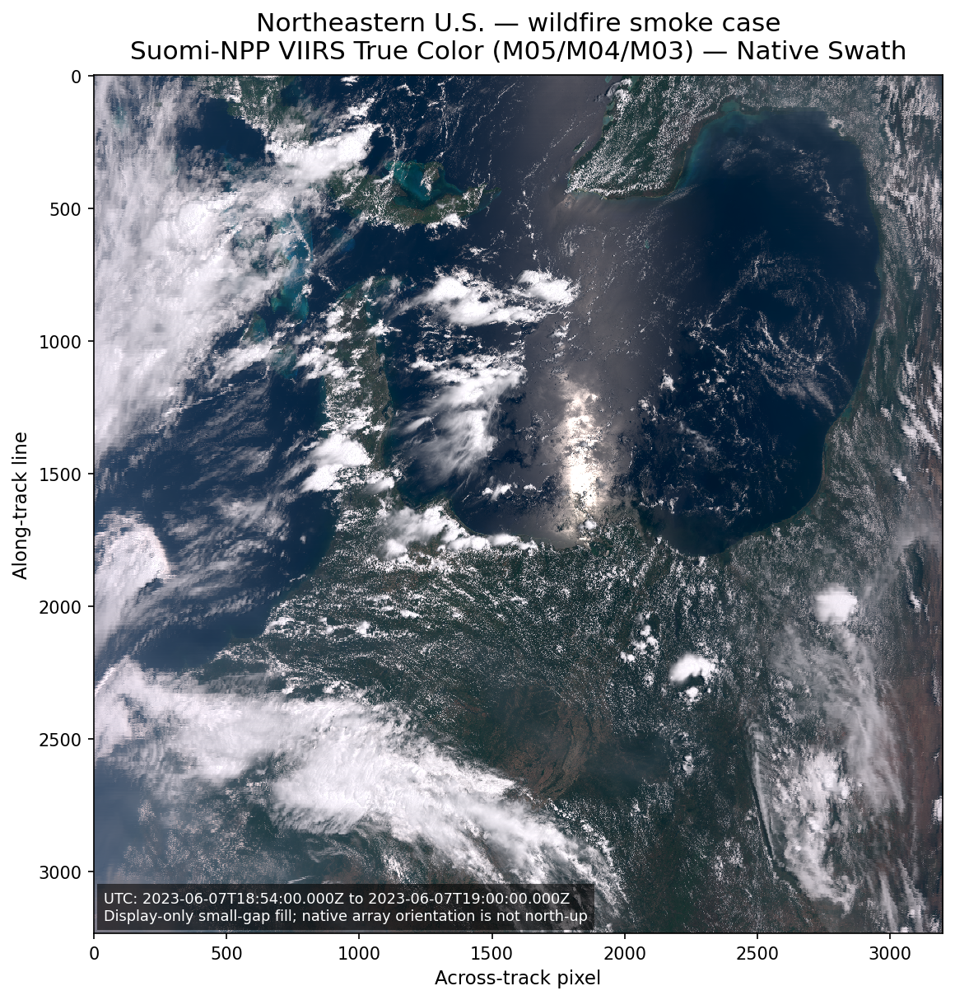

/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_1_states_provinces_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


Saved: /content/Mirza_VIIRS_Plots_outputs/outputs/figures/scene1_projected_true_color_700dpi.png


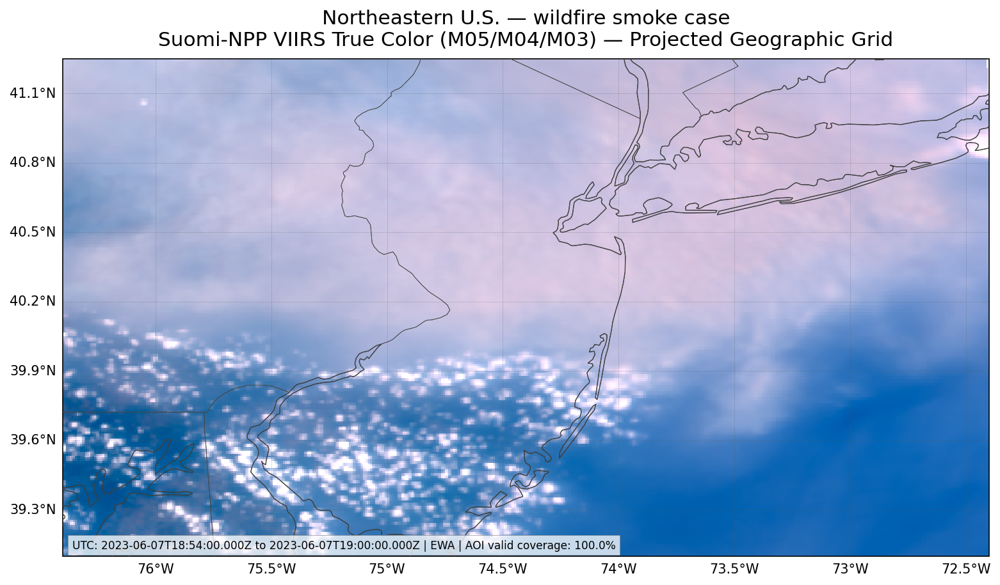


scene1 projection method : EWA
scene1 AOI valid coverage : 100.0%

Generating figures for scene2: Florida — Hurricane Ian case
Saved: /content/Mirza_VIIRS_Plots_outputs/outputs/figures/scene2_unprojected_true_color_700dpi.png


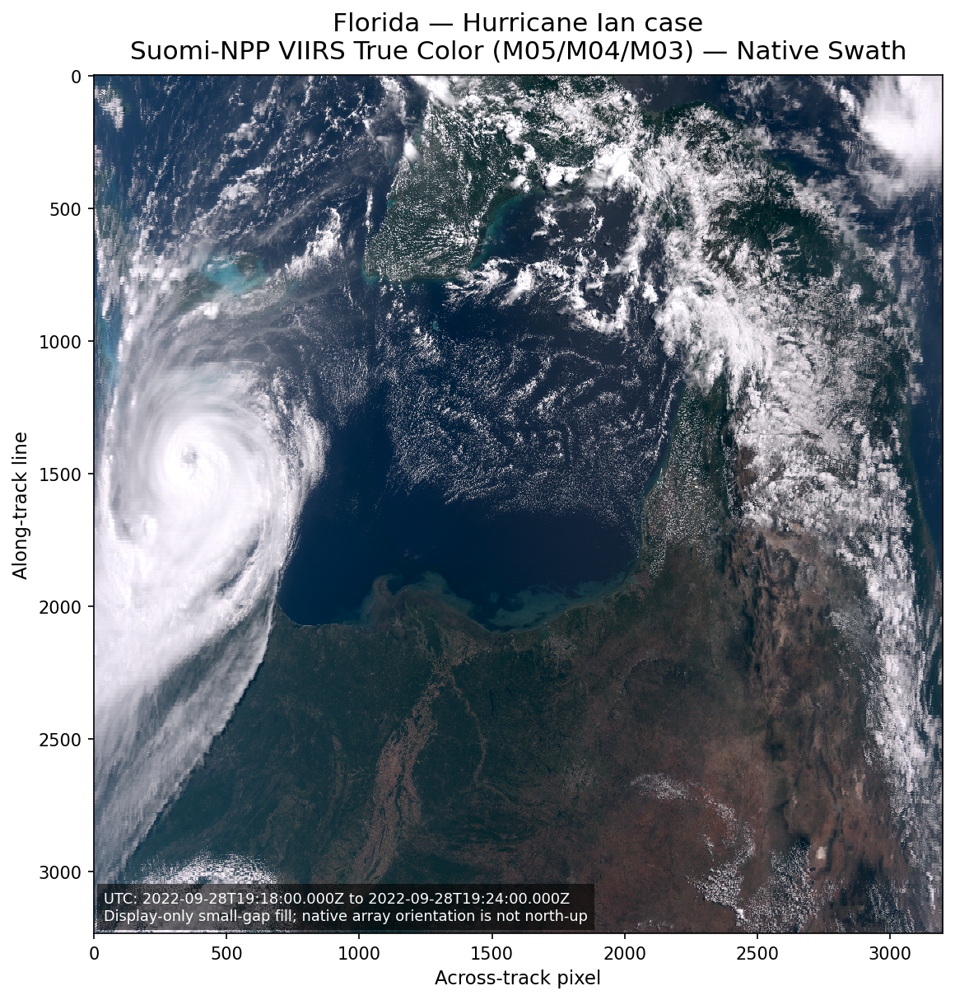

Saved: /content/Mirza_VIIRS_Plots_outputs/outputs/figures/scene2_projected_true_color_700dpi.png


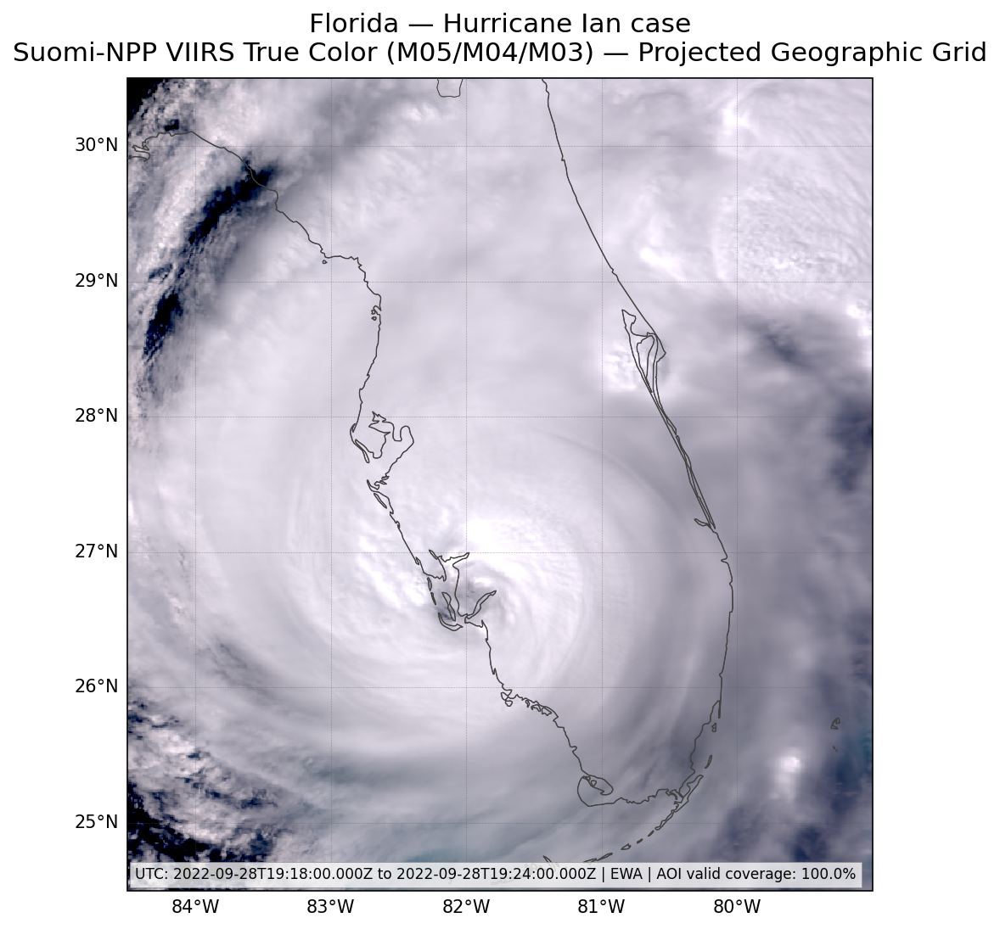


scene2 projection method : EWA
scene2 AOI valid coverage : 100.0%

FOUR REQUIRED VIIRS FIGURES
1. /content/Mirza_VIIRS_Plots_outputs/outputs/figures/scene1_unprojected_true_color_700dpi.png
2. /content/Mirza_VIIRS_Plots_outputs/outputs/figures/scene1_projected_true_color_700dpi.png
3. /content/Mirza_VIIRS_Plots_outputs/outputs/figures/scene2_unprojected_true_color_700dpi.png
4. /content/Mirza_VIIRS_Plots_outputs/outputs/figures/scene2_projected_true_color_700dpi.png

✓ Native Scene 1 and Scene 2 use identical figure dimensions.
✓ Projected maps preserve their geographic AOI aspect ratios.
✓ All figures use Suomi-NPP VIIRS M05/M04/M03 true color.
✓ Projected imagery retains the configured EWA/resampling workflow.
✓ Figures saved using the notebook's 700-dpi export function.


In [ ]:
# CODE CELL 11 — GENERATE FOUR REQUIRED PART (A) FIGURES
# ============================================================
# FINAL FOUR REQUIRED VIIRS SCENE FIGURES
#
# Native swaths:
#   - same figure dimensions for direct comparison
#
# Projected maps:
#   - preserve geographic AOI aspect ratio
#   - DO NOT stretch different geographic regions
#
# All:
#   - consistent titles
#   - M05/M04/M03 explicitly identified
#   - 700-dpi output
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


scene_figure_paths = []

# Fixed size only for native-swath figures
NATIVE_FIGSIZE = (10.2, 8.2)


for scene in SCENES:

    sid = scene["id"]
    d = scenes_data[sid]

    print("\n" + "=" * 70)
    print(f"Generating figures for {sid}: {scene['label']}")
    print("=" * 70)


    # ========================================================
    # RESET PROJECTED PRODUCTS
    #
    # Forces projected imagery to be regenerated cleanly
    # from the current processing configuration.
    # ========================================================

    d.pop("projected_rgb", None)
    d.pop("projection_method", None)
    d.pop("projected_coverage_pct", None)


    # ========================================================
    # FIGURE 1 / 3 — NATIVE VIIRS SWATH
    # ========================================================

    fig = plot_unprojected(
        scene,
        d
    )

    # Native figures should use identical dimensions
    fig.set_size_inches(
        NATIVE_FIGSIZE[0],
        NATIVE_FIGSIZE[1],
        forward=True
    )

    ax = fig.axes[0]

    # Standardized title
    ax.set_title(
        f"{scene['label']}\n"
        "Suomi-NPP VIIRS True Color (M05/M04/M03) — Native Swath",
        fontsize=15,
        pad=10
    )

    ax.set_xlabel(
        "Across-track pixel",
        fontsize=11
    )

    ax.set_ylabel(
        "Along-track line",
        fontsize=11
    )

    ax.tick_params(
        labelsize=10
    )

    fig.tight_layout()


    native_path = savefig700(
        fig,
        f"{sid}_unprojected_true_color_700dpi.png"
    )

    scene_figure_paths.append(
        native_path
    )

    plt.show()
    plt.close(fig)


    # ========================================================
    # FIGURE 2 / 4 — PROJECTED GEOGRAPHIC MAP
    # ========================================================
    #
    # IMPORTANT:
    # plot_projected() determines an appropriate figure shape
    # from the AOI. Do NOT force it to NATIVE_FIGSIZE.
    #
    # Northeast AOI is geographically wide -> wider figure.
    # Florida AOI is more N-S / square -> taller figure.
    #
    # This preserves geographic presentation instead of
    # artificially stretching the imagery.
    # ========================================================

    fig = plot_projected(
        scene,
        d
    )

    ax = fig.axes[0]

    # Standardized projected-map title
    ax.set_title(
        f"{scene['label']}\n"
        "Suomi-NPP VIIRS True Color (M05/M04/M03) "
        "— Projected Geographic Grid",
        fontsize=15,
        pad=10
    )

    # Do not manually force the projected figure dimensions.
    # Geographic aspect ratio should be retained.

    fig.tight_layout()


    projected_path = savefig700(
        fig,
        f"{sid}_projected_true_color_700dpi.png"
    )

    scene_figure_paths.append(
        projected_path
    )

    plt.show()
    plt.close(fig)


    # ========================================================
    # PROCESSING DIAGNOSTICS
    # ========================================================

    method = d.get(
        "projection_method",
        "unknown"
    )

    coverage = d.get(
        "projected_coverage_pct",
        np.nan
    )

    print(
        f"\n{sid} projection method : {method}"
    )

    if np.isfinite(coverage):

        print(
            f"{sid} AOI valid coverage : "
            f"{coverage:.1f}%"
        )

    else:

        print(
            f"{sid} AOI valid coverage : unavailable"
        )


# ============================================================
# FINAL OUTPUT SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FOUR REQUIRED VIIRS FIGURES")
print("=" * 70)

for i, path in enumerate(
    scene_figure_paths,
    start=1
):

    print(
        f"{i}. {path}"
    )


print(
    "\n✓ Native Scene 1 and Scene 2 use identical figure dimensions."
)

print(
    "✓ Projected maps preserve their geographic AOI aspect ratios."
)

print(
    "✓ All figures use Suomi-NPP VIIRS M05/M04/M03 true color."
)

print(
    "✓ Projected imagery retains the configured EWA/resampling workflow."
)

print(
    "✓ Figures saved using the notebook's 700-dpi export function."
)

**Code Cell 12 — Part (b) acquisition time and scene feature**

# Part (b) — Acquisition time and principal scene feature

**Now I will extract the acquisition start/end time from the granule metadata and pair it with the principal feature for each case study.** This produces a concise table for the written homework and saves it as a CSV.

The feature descriptions are used as documentation support; the final interpretation should still be based on the generated imagery.


In [ ]:
# CODE CELL 12 — PART (B) ACQUISITION TIME AND SCENE FEATURE
scene_report = metadata_df[
    ["scene", "label", "start_UTC", "end_UTC"]
].copy()

scene_report["main_feature"] = [
    s["feature_note"] for s in SCENES
]

display(scene_report)

scene_report.to_csv(
    OUTPUT_DIR / "scene_date_time_and_features.csv",
    index=False
)

,scene,label,start_UTC,end_UTC,main_feature
0,scene1,Northeastern U.S. — wildfire smoke case,2023-06-07T18:54:00.000Z,2023-06-07T19:00:00.000Z,Widespread smoke/haze over the Mid-Atlantic an...
1,scene2,Florida — Hurricane Ian case,2022-09-28T19:18:00.000Z,2022-09-28T19:24:00.000Z,Hurricane Ian's dense cloud shield and spiral ...


**Code Cell 13 — Part (c) binary radiance export**

# Part (c) — Export the five required radiance bands as binary files

**Now I will save M03 (blue), M04 (green), M05 (red), M15 (~11 µm), and M16 (~12 µm) radiance for both scenes.** Each array is written as little-endian `float32` in C row-major order, with `NaN` representing invalid data. A JSON sidecar records the band, wavelength, units, array shape, and source filename.

For the current **3232 × 3200** arrays, each binary `float32` file is approximately **39.45 MiB**. With two scenes and five required bands, this step produces **10 binary files** plus **10 JSON sidecars**.


In [ ]:
# CODE CELL 13 — PART (C) BINARY RADIANCE EXPORT
def save_binary(array, path, meta):
    if array is None:
        raise RuntimeError(f"Cannot save {path.name}: radiance array is None.")

    arr = np.asarray(array, dtype="<f4")
    arr.tofile(path)

    sidecar = {
        **meta,
        "dtype":"float32 little-endian",
        "shape":list(arr.shape),
        "order":"C row-major",
        "invalid_values":"NaN"
    }

    mpath = Path(str(path)+".json")
    with open(mpath,"w") as f:
        json.dump(sidecar,f,indent=2)

    return path, mpath

manifest = []

for sid,d in scenes_data.items():
    for label,b in REQUIRED_FIVE.items():
        a = d["bands"][b]["radiance"]

        if a is None:
            raise RuntimeError(
                f"Radiance is None for {sid} {b}. "
                "Re-run the corrected calibration and scene-loading cells."
            )

        p = BINARY_DIR/f"{sid}_{label}_{b}_radiance_float32.bin"

        save_binary(
            a,
            p,
            {
                "scene":sid,
                "band":b,
                "description":label,
                "center_wavelength_um":BAND_CENTERS_UM[b],
                "quantity":"spectral radiance",
                "units":d["bands"][b]["radiance_units"],
                "source":scene_files[sid]["radiance_name"]
            }
        )

        manifest.append({
            "scene":sid,
            "band":b,
            "description":label,
            "file":str(p),
            "shape":a.shape
        })

manifest_df = pd.DataFrame(manifest)
display(manifest_df)
manifest_df.to_csv(OUTPUT_DIR/"binary_file_manifest.csv", index=False)

print("Binary radiance files created:", len(manifest_df))

,scene,band,description,file,shape
0,scene1,M03,blue,/content/Mirza_VIIRS_Plots_outputs/outputs/bin...,"(3232, 3200)"
1,scene1,M04,green,/content/Mirza_VIIRS_Plots_outputs/outputs/bin...,"(3232, 3200)"
2,scene1,M05,red,/content/Mirza_VIIRS_Plots_outputs/outputs/bin...,"(3232, 3200)"
3,scene1,M15,thermal_11um,/content/Mirza_VIIRS_Plots_outputs/outputs/bin...,"(3232, 3200)"
4,scene1,M16,thermal_12um,/content/Mirza_VIIRS_Plots_outputs/outputs/bin...,"(3232, 3200)"
5,scene2,M03,blue,/content/Mirza_VIIRS_Plots_outputs/outputs/bin...,"(3232, 3200)"
6,scene2,M04,green,/content/Mirza_VIIRS_Plots_outputs/outputs/bin...,"(3232, 3200)"
7,scene2,M05,red,/content/Mirza_VIIRS_Plots_outputs/outputs/bin...,"(3232, 3200)"
8,scene2,M15,thermal_11um,/content/Mirza_VIIRS_Plots_outputs/outputs/bin...,"(3232, 3200)"
9,scene2,M16,thermal_12um,/content/Mirza_VIIRS_Plots_outputs/outputs/bin...,"(3232, 3200)"


Binary radiance files created: 10


**Code Cell 14 — Part (d) final reference pixels and M06 QA**

# Part (d) — Clear-land vs cloud spectral signatures

For Scene 1, I use two final representative native pixels that have already been checked against both the projected map and the native swath:

- clear inland land: row 2994, column 231
- cloud: row 2969, column 176

**Now I will document these fixed reference pixels and inspect the M06 quality information.** The M06 `Out_of_Range` flag is set for both selected pixels, so I will mask M06 in the spectral plots rather than inventing, smoothing, or physically interpreting that measurement.


In [ ]:
# CODE CELL 14 — PART (D) FINAL REFERENCE PIXELS AND M06 QA
# ============================================================
# FINAL SCENE 1 REFERENCE PIXELS + M06 QA
# ============================================================

import numpy as np
import pandas as pd
from netCDF4 import Dataset


# ------------------------------------------------------------
# Scene
# ------------------------------------------------------------

SPECTRAL_SCENE_ID = "scene1"

sd = scenes_data[SPECTRAL_SCENE_ID]

rad_path = scene_files[
    SPECTRAL_SCENE_ID
]["radiance_path"]


# ------------------------------------------------------------
# Final representative pixels
#
# These pixels were already checked using:
#   1. projected geographic image
#   2. native VIIRS swath
#   3. visible/NIR spectral behavior
#   4. thermal brightness temperature
#
# We keep these physically representative pixels.
# M06 will be treated separately using its QA flag.
# ------------------------------------------------------------

land_idx = (2994, 231)
cloud_idx = (2969, 176)


# ------------------------------------------------------------
# VIIRS pixel-quality reader
# ------------------------------------------------------------

def read_pixel_quality(rad_path, band, idx):

    i, j = idx

    with Dataset(rad_path) as ds:

        obs = ds.groups["observation_data"]

        qname = f"{band}_quality_flags"
        uname = f"{band}_uncert_index"

        if qname in obs.variables:
            qflag = int(obs.variables[qname][i, j])
        else:
            qflag = None

        if uname in obs.variables:
            uncert = int(obs.variables[uname][i, j])
        else:
            uncert = None

    return qflag, uncert


# ------------------------------------------------------------
# M06 quality bit
#
# Bit value 2 = Out_of_Range
# ------------------------------------------------------------

M06_OUT_OF_RANGE = 2


# ------------------------------------------------------------
# Build summary for selected pixels
# ------------------------------------------------------------

def selection_summary(idx, name):

    i, j = idx

    m03 = float(
        sd["bands"]["M03"]["reflectance"][i, j]
    )

    m04 = float(
        sd["bands"]["M04"]["reflectance"][i, j]
    )

    m05 = float(
        sd["bands"]["M05"]["reflectance"][i, j]
    )

    m06 = float(
        sd["bands"]["M06"]["reflectance"][i, j]
    )

    m07 = float(
        sd["bands"]["M07"]["reflectance"][i, j]
    )

    bt15 = float(
        sd["bands"]["M15"]["bt"][i, j]
    )

    # NDVI-like vegetation contrast
    denom = m07 + m05

    ndvi = (
        (m07 - m05) / denom
        if denom != 0
        else np.nan
    )

    # M06 QA
    qflag_m06, uncert_m06 = read_pixel_quality(
        rad_path,
        "M06",
        idx
    )

    m06_out_of_range = (
        qflag_m06 is not None
        and
        (qflag_m06 & M06_OUT_OF_RANGE) != 0
    )

    return {

        "pixel_type": name,

        "row": i,
        "column": j,

        "latitude":
            float(sd["lat"][i, j]),

        "longitude":
            float(sd["lon"][i, j]),

        "M03_reflectance": m03,
        "M04_reflectance": m04,
        "M05_reflectance": m05,
        "M06_reflectance_raw": m06,
        "M07_reflectance": m07,

        "NDVI_like": ndvi,

        "M15_BT_K": bt15,

        "M06_quality_flag_raw":
            qflag_m06,

        "M06_Out_of_Range":
            m06_out_of_range,

        "M06_uncert_index":
            uncert_m06
    }


# ------------------------------------------------------------
# Summary table
# ------------------------------------------------------------

selection_df = pd.DataFrame([
    selection_summary(
        land_idx,
        "Clear inland land"
    ),

    selection_summary(
        cloud_idx,
        "Cloud"
    )
])


display(selection_df)


# ------------------------------------------------------------
# Print final selection
# ------------------------------------------------------------

print("\nFinal representative Scene 1 pixels:")

print(
    f"Land  : row={land_idx[0]}, "
    f"column={land_idx[1]}, "
    f"lat={sd['lat'][land_idx]:.4f}, "
    f"lon={sd['lon'][land_idx]:.4f}"
)

print(
    f"Cloud : row={cloud_idx[0]}, "
    f"column={cloud_idx[1]}, "
    f"lat={sd['lat'][cloud_idx]:.4f}, "
    f"lon={sd['lon'][cloud_idx]:.4f}"
)


# ------------------------------------------------------------
# M06 interpretation warning
# ------------------------------------------------------------

for _, row in selection_df.iterrows():

    if row["M06_Out_of_Range"]:

        print(
            f"⚠ {row['pixel_type']}: "
            "M06 is flagged Out_of_Range "
            "and must be masked in the spectral plot."
        )

    else:

        print(
            f"✓ {row['pixel_type']}: "
            "M06 passed the Out_of_Range QA check."
        )


print(
    "\n✓ Pixel selection is complete. "
    "Do not reselect the land/cloud targets because of M06."
)

,pixel_type,row,column,latitude,longitude,M03_reflectance,M04_reflectance,M05_reflectance,M06_reflectance_raw,M07_reflectance,NDVI_like,M15_BT_K,M06_quality_flag_raw,M06_Out_of_Range,M06_uncert_index
0,Clear inland land,2994,231,39.674736,-75.929955,0.261323,0.213216,0.175423,0.185529,0.396761,0.386830,295.683563,2,True,0
1,Cloud,2969,176,39.575203,-75.188866,0.555795,0.538848,0.637377,0.178975,0.813592,0.121447,269.281097,2,True,0



Final representative Scene 1 pixels:
Land  : row=2994, column=231, lat=39.6747, lon=-75.9300
Cloud : row=2969, column=176, lat=39.5752, lon=-75.1889
⚠ Clear inland land: M06 is flagged Out_of_Range and must be masked in the spectral plot.
⚠ Cloud: M06 is flagged Out_of_Range and must be masked in the spectral plot.

✓ Pixel selection is complete. Do not reselect the land/cloud targets because of M06.


**Code Cell 15 — Part (d) QA-masked reflective spectra**

### Prepare QA-masked reflective spectra

**Now I will extract M01–M11 reflectance for the two selected pixels and apply the M06 QA decision.** M06 remains in the band sequence but is replaced with `NaN` for both pixels because its `Out_of_Range` bit is set.

Expected result: all other reflective bands retain their measured values, while M06 prints as `nan` for land and cloud.


In [ ]:
# CODE CELL 15 — PART (D) QA-MASKED REFLECTIVE SPECTRA
# ============================================================
# PREPARE QA-MASKED REFLECTIVE SPECTRA
# ============================================================

import numpy as np

# ------------------------------------------------------------
# Reflective VIIRS M-bands
# ------------------------------------------------------------

reflective_bands = [
    "M01", "M02", "M03", "M04", "M05",
    "M06", "M07", "M08", "M09", "M10", "M11"
]

# Approximate center wavelengths [µm]
VIIRS_M_WAVELENGTH = {
    "M01": 0.412,
    "M02": 0.445,
    "M03": 0.488,
    "M04": 0.555,
    "M05": 0.672,
    "M06": 0.746,
    "M07": 0.865,
    "M08": 1.240,
    "M09": 1.378,
    "M10": 1.610,
    "M11": 2.250
}

reflective_wavelengths = np.array([
    VIIRS_M_WAVELENGTH[b]
    for b in reflective_bands
])


# ------------------------------------------------------------
# Extract reflectance spectra from final selected pixels
# ------------------------------------------------------------

land_refl = np.array([
    float(
        sd["bands"][band]["reflectance"][
            land_idx[0],
            land_idx[1]
        ]
    )
    for band in reflective_bands
])

cloud_refl = np.array([
    float(
        sd["bands"][band]["reflectance"][
            cloud_idx[0],
            cloud_idx[1]
        ]
    )
    for band in reflective_bands
])


# ------------------------------------------------------------
# Mask M06 if Out_of_Range QA bit is set
# ------------------------------------------------------------

m06_pos = reflective_bands.index("M06")

for idx, spectrum, name in [
    (land_idx, land_refl, "Clear inland land"),
    (cloud_idx, cloud_refl, "Cloud")
]:

    qflag, uncert = read_pixel_quality(
        rad_path,
        "M06",
        idx
    )

    if (
        qflag is not None
        and
        (qflag & M06_OUT_OF_RANGE) != 0
    ):

        spectrum[m06_pos] = np.nan

        print(
            f"{name}: M06 masked "
            f"(quality flag={qflag}, Out_of_Range)"
        )

    else:

        print(
            f"{name}: M06 retained "
            f"(quality flag={qflag})"
        )


# ------------------------------------------------------------
# Diagnostic output
# ------------------------------------------------------------

print("\nFinal reflective spectra used for plotting:")

for i, band in enumerate(reflective_bands):

    print(
        f"{band:>3s}  "
        f"{reflective_wavelengths[i]:5.3f} µm   "
        f"Land={land_refl[i]}   "
        f"Cloud={cloud_refl[i]}"
    )

print(
    "\n✓ Reflective spectra prepared. "
    "QA-flagged M06 values are represented as NaN."
)

Clear inland land: M06 masked (quality flag=2, Out_of_Range)
Cloud: M06 masked (quality flag=2, Out_of_Range)

Final reflective spectra used for plotting:
M01  0.412 µm   Land=0.35250741598289187   Cloud=0.5481906847206722
M02  0.445 µm   Land=0.30735379554314063   Cloud=0.5446900168109698
M03  0.488 µm   Land=0.26132340577446217   Cloud=0.555794784551019
M04  0.555 µm   Land=0.2132164570688509   Cloud=0.5388478425510693
M05  0.672 µm   Land=0.1754230844166728   Cloud=0.6373765751089165
M06  0.746 µm   Land=nan   Cloud=nan
M07  0.865 µm   Land=0.39676119421663886   Cloud=0.8135923153847278
M08  1.240 µm   Land=0.3877627721565965   Cloud=0.8639694767607753
M09  1.378 µm   Land=0.004406919521713074   Cloud=0.057934894744014205
M10  1.610 µm   Land=0.23700459333527069   Cloud=0.7537100292207466
M11  2.250 µm   Land=0.11926370161117739   Cloud=0.5868371311145385

✓ Reflective spectra prepared. QA-flagged M06 values are represented as NaN.


**Code Cell 16 — Part (d) projected selected-pixel map**

### Verify the selected pixels on the projected map

**Now I will place the two final reference pixels on the Scene 1 projected true-color map.** This verifies their geographic context: the green circle should lie on clear inland land, and the cyan `×` should lie on a bright cloud feature.

Figure canvas: **10 × 7.2 inches**.


Saved: /content/Mirza_VIIRS_Plots_outputs/outputs/figures/scene1_selected_pixels_projected_700dpi.png


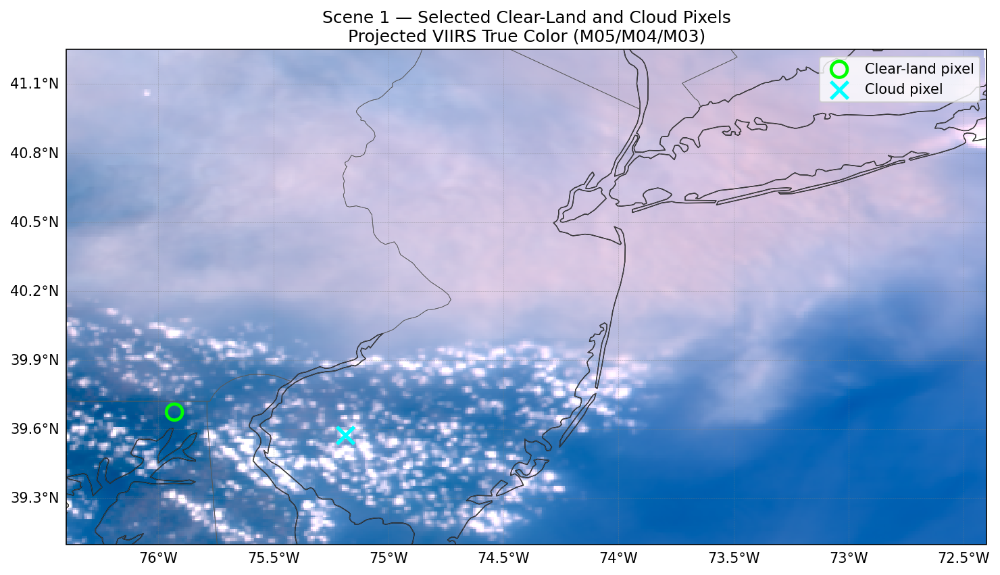

In [ ]:
# CODE CELL 16 — PART (D) PROJECTED SELECTED-PIXEL MAP
# ============================================================
# PROJECTED FIGURE — SCENE 1 SELECTED CLEAR-LAND AND CLOUD PIXELS
# ============================================================

scene1_cfg = SCENES[0]
sd = scenes_data["scene1"]

w, s, e, n = scene1_cfg["bbox"]

# Build projected RGB if it does not already exist
if ("projected_rgb" not in sd) or (sd["projected_rgb"] is None):
    (
        sd["projected_rgb"],
        sd["projection_method"],
        sd["projected_coverage_pct"]
    ) = project_rgb(
        scene1_cfg,
        sd,
        GRID_RES_DEG
    )

rgbp = sd["projected_rgb"]

valid_rgb = np.all(np.isfinite(rgbp), axis=2)
rgb_display = np.nan_to_num(rgbp, nan=0.0)
rgba = np.dstack([rgb_display, valid_rgb.astype(float)])

fig = plt.figure(figsize=(10, 7.2))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.imshow(
    rgba,
    origin="upper",
    extent=[w, e, s, n],
    transform=ccrs.PlateCarree(),
    interpolation="nearest"
)

ax.add_feature(
    cfeature.COASTLINE.with_scale("10m"),
    linewidth=0.7
)

ax.add_feature(
    cfeature.STATES.with_scale("10m"),
    linewidth=0.35,
    edgecolor="0.35"
)

li, lj = land_idx
ci, cj = cloud_idx

land_lon = sd["lon"][li, lj]
land_lat = sd["lat"][li, lj]
cloud_lon = sd["lon"][ci, cj]
cloud_lat = sd["lat"][ci, cj]

ax.scatter(
    land_lon,
    land_lat,
    s=130,
    facecolors="none",
    edgecolors="lime",
    linewidths=2.3,
    transform=ccrs.PlateCarree(),
    label="Clear-land pixel",
    zorder=10
)

ax.scatter(
    cloud_lon,
    cloud_lat,
    s=150,
    marker="x",
    color="cyan",
    linewidths=2.5,
    transform=ccrs.PlateCarree(),
    label="Cloud pixel",
    zorder=10
)

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.3,
    color="gray",
    alpha=0.5,
    linestyle="--"
)
gl.top_labels = False
gl.right_labels = False

ax.set_extent(
    [w, e, s, n],
    crs=ccrs.PlateCarree()
)

ax.set_title(
    "Scene 1 — Selected Clear-Land and Cloud Pixels\n"
    "Projected VIIRS True Color (M05/M04/M03)"
)

ax.legend(loc="upper right", frameon=True)

fig.tight_layout()

savefig700(
    fig,
    "scene1_selected_pixels_projected_700dpi.png"
)

plt.show()
plt.close(fig)

**Code Cell 17 — Part (d) native-swath selected-pixel figure**

### Verify the same pixels in native VIIRS geometry

**Now I will show the same row/column locations in the original VIIRS swath.** Panel A provides full-swath context and Panel B enlarges the exact native-pixel neighborhood. This confirms that the spectral values come from original VIIRS array pixels rather than from resampled projected pixels.

Figure canvas: **16 × 8.8 inches**.


Native-array selected pixels:
  Clear inland land : row=2994, column=231
  Cloud             : row=2969, column=176
Saved: /content/Mirza_VIIRS_Plots_outputs/outputs/figures/scene1_selected_pixels_native_swath_700dpi.png


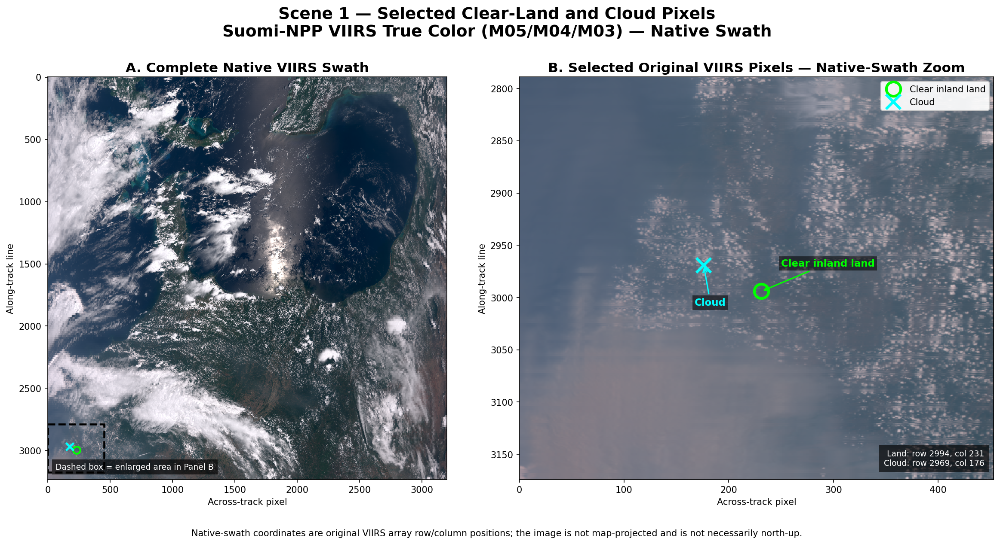

In [ ]:
# CODE CELL 17 — PART (D) NATIVE-SWATH SELECTED-PIXEL FIGURE
# ============================================================
# Full-swath overview + zoomed native-pixel view
#
# Now I will show the same clear-land and cloud pixels in the
# original VIIRS detector/swath geometry. This confirms exactly
# which native array pixels were used for the spectral analysis.
#
# Native VIIRS array size:
#   3232 along-track lines × 3200 across-track pixels
#
# Important:
#   This image is NOT map-projected and is not necessarily
#   north-up. Pixel coordinates are original array row/column
#   positions.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


# ------------------------------------------------------------
# Scene and native RGB
# ------------------------------------------------------------

SPECTRAL_SCENE_ID = "scene1"
sd = scenes_data[SPECTRAL_SCENE_ID]

rgb_native = np.asarray(
    sd["rgb"]
).copy()

rgb_native = np.nan_to_num(
    rgb_native,
    nan=0.0,
    posinf=1.0,
    neginf=0.0
)

rgb_native = np.clip(
    rgb_native,
    0.0,
    1.0
)


# ------------------------------------------------------------
# Final selected native VIIRS pixels
# ------------------------------------------------------------

land_row, land_col = land_idx
cloud_row, cloud_col = cloud_idx

print("Native-array selected pixels:")
print(
    f"  Clear inland land : "
    f"row={land_row}, column={land_col}"
)
print(
    f"  Cloud             : "
    f"row={cloud_row}, column={cloud_col}"
)


# ============================================================
# DEFINE ZOOM WINDOW
# ============================================================

nrows, ncols = rgb_native.shape[:2]

row_margin = 180
col_margin = 220


r0 = max(
    0,
    min(land_row, cloud_row) - row_margin
)

r1 = min(
    nrows,
    max(land_row, cloud_row) + row_margin
)

c0 = max(
    0,
    min(land_col, cloud_col) - col_margin
)

c1 = min(
    ncols,
    max(land_col, cloud_col) + col_margin
)


# ------------------------------------------------------------
# Guarantee a useful minimum zoom size
# ------------------------------------------------------------

minimum_rows = 350
minimum_cols = 500


if (r1 - r0) < minimum_rows:

    center_r = int(
        (land_row + cloud_row) / 2
    )

    half = minimum_rows // 2

    r0 = max(
        0,
        center_r - half
    )

    r1 = min(
        nrows,
        center_r + half
    )

    if (r1 - r0) < minimum_rows:

        r0 = max(
            0,
            r1 - minimum_rows
        )


if (c1 - c0) < minimum_cols:

    center_c = int(
        (land_col + cloud_col) / 2
    )

    half = minimum_cols // 2

    c0 = max(
        0,
        center_c - half
    )

    c1 = min(
        ncols,
        center_c + half
    )

    if (c1 - c0) < minimum_cols:

        c0 = max(
            0,
            c1 - minimum_cols
        )


# ------------------------------------------------------------
# Crop directly from original native array
# ------------------------------------------------------------

rgb_zoom = rgb_native[
    r0:r1,
    c0:c1,
    :
]


# ============================================================
# CREATE FIGURE
#
# Canvas size: 16 × 8.8 inches
# ============================================================

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(16, 8.8),
    gridspec_kw={
        "width_ratios": [
            1.00,
            1.15
        ]
    }
)


# ============================================================
# PANEL A — COMPLETE NATIVE SWATH
# ============================================================

ax1.imshow(
    rgb_native,
    origin="upper",
    interpolation="nearest"
)


# ------------------------------------------------------------
# Show zoom-region box
# ------------------------------------------------------------

zoom_box = Rectangle(
    (c0, r0),
    c1 - c0,
    r1 - r0,
    fill=False,
    linewidth=2.2,
    linestyle="--"
)

ax1.add_patch(
    zoom_box
)


# ------------------------------------------------------------
# Show selected pixels on full swath
# ------------------------------------------------------------

ax1.plot(
    land_col,
    land_row,
    marker="o",
    markersize=8,
    markerfacecolor="none",
    markeredgecolor="lime",
    markeredgewidth=2,
    linestyle="none",
    zorder=10
)

ax1.plot(
    cloud_col,
    cloud_row,
    marker="x",
    markersize=9,
    markeredgewidth=2.3,
    color="cyan",
    linestyle="none",
    zorder=10
)


ax1.set_title(
    "A. Complete Native VIIRS Swath",
    fontsize=15,
    fontweight="bold"
)

ax1.set_xlabel(
    "Across-track pixel"
)

ax1.set_ylabel(
    "Along-track line"
)


ax1.text(
    0.02,
    0.025,
    "Dashed box = enlarged area in Panel B",
    transform=ax1.transAxes,
    fontsize=9,
    color="white",
    bbox=dict(
        facecolor="black",
        alpha=0.65,
        edgecolor="none",
        pad=4
    )
)


# ============================================================
# PANEL B — ZOOMED ORIGINAL VIIRS PIXELS
# ============================================================

ax2.imshow(
    rgb_zoom,
    origin="upper",
    interpolation="nearest",
    extent=[
        c0,
        c1,
        r1,
        r0
    ]
)


# Explicitly retain native row/column orientation
ax2.set_xlim(
    c0,
    c1
)

ax2.set_ylim(
    r1,
    r0
)


# ------------------------------------------------------------
# Clear-land pixel
# ------------------------------------------------------------

ax2.plot(
    land_col,
    land_row,
    marker="o",
    markersize=16,
    markerfacecolor="none",
    markeredgecolor="lime",
    markeredgewidth=3,
    linestyle="none",
    label="Clear inland land",
    zorder=20
)


ax2.annotate(
    "Clear inland land",
    xy=(
        land_col,
        land_row
    ),
    xytext=(
        22,
        28
    ),
    textcoords="offset points",
    fontsize=11,
    fontweight="bold",
    color="lime",
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.5,
        color="lime"
    ),
    bbox=dict(
        facecolor="black",
        alpha=0.55,
        edgecolor="none",
        pad=2.5
    ),
    zorder=30
)


# ------------------------------------------------------------
# Cloud pixel
# ------------------------------------------------------------

ax2.plot(
    cloud_col,
    cloud_row,
    marker="x",
    markersize=16,
    markeredgewidth=3,
    color="cyan",
    linestyle="none",
    label="Cloud",
    zorder=20
)


ax2.annotate(
    "Cloud",
    xy=(
        cloud_col,
        cloud_row
    ),
    xytext=(
        -10,
        -45
    ),
    textcoords="offset points",
    fontsize=11,
    fontweight="bold",
    color="cyan",
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.5,
        color="cyan"
    ),
    bbox=dict(
        facecolor="black",
        alpha=0.55,
        edgecolor="none",
        pad=2.5
    ),
    zorder=30
)


# ------------------------------------------------------------
# Native pixel coordinates
# ------------------------------------------------------------

info_text = (
    f"Land: row {land_row}, col {land_col}\n"
    f"Cloud: row {cloud_row}, col {cloud_col}"
)

ax2.text(
    0.98,
    0.03,
    info_text,
    transform=ax2.transAxes,
    fontsize=9,
    color="white",
    ha="right",
    va="bottom",
    bbox=dict(
        facecolor="black",
        alpha=0.65,
        edgecolor="none",
        pad=5
    )
)


ax2.set_title(
    "B. Selected Original VIIRS Pixels — Native-Swath Zoom",
    fontsize=15,
    fontweight="bold"
)

ax2.set_xlabel(
    "Across-track pixel"
)

ax2.set_ylabel(
    "Along-track line"
)

ax2.legend(
    loc="upper right",
    fontsize=10,
    framealpha=0.92
)


# ============================================================
# MAIN TITLE
# ============================================================

fig.suptitle(
    "Scene 1 — Selected Clear-Land and Cloud Pixels\n"
    "Suomi-NPP VIIRS True Color (M05/M04/M03) — Native Swath",
    fontsize=18,
    fontweight="bold",
    y=0.965
)


# ============================================================
# LAYOUT
#
# Extra bottom margin is intentionally reserved for the
# scientific note so it cannot overlap the x-axis labels.
# ============================================================

fig.subplots_adjust(
    left=0.055,
    right=0.985,
    bottom=0.13,
    top=0.84,
    wspace=0.13
)


# ============================================================
# SCIENTIFIC NOTE
# ============================================================

fig.text(
    0.5,
    0.035,
    "Native-swath coordinates are original VIIRS array "
    "row/column positions; the image is not map-projected "
    "and is not necessarily north-up.",
    ha="center",
    va="center",
    fontsize=10
)


# ============================================================
# SAVE AND DISPLAY
# ============================================================

savefig700(
    fig,
    "scene1_selected_pixels_native_swath_700dpi.png"
)

plt.show()
plt.close(fig)

**Code Cell 18 — Part (d) land/cloud spectral comparison**

### Compare land and cloud spectral behavior

**Now I will compare the two pixels using the physically appropriate quantity for each spectral region.** M01–M11 are shown as reflectance, daytime M12–M13 are shown as radiance because reflected solar and emitted thermal energy can both contribute, and M14–M16 are shown as brightness temperature.

M06 stays masked because of the QA flag. M09 is expected to be strongly affected by atmospheric water-vapor absorption near 1.38 µm.

Figure canvas: **18 × 6.5 inches**.


✓ Using QA-masked M01–M11 spectra.
✓ M06 is excluded for both selected pixels.

Scene 1 spectral comparison
Clear land : row=2994, col=231, lat=39.6747, lon=-75.9300
Cloud      : row=2969, col=176, lat=39.5752, lon=-75.1889
Saved: /content/Mirza_VIIRS_Plots_outputs/outputs/figures/scene1_land_cloud_spectral_comparison_700dpi.png


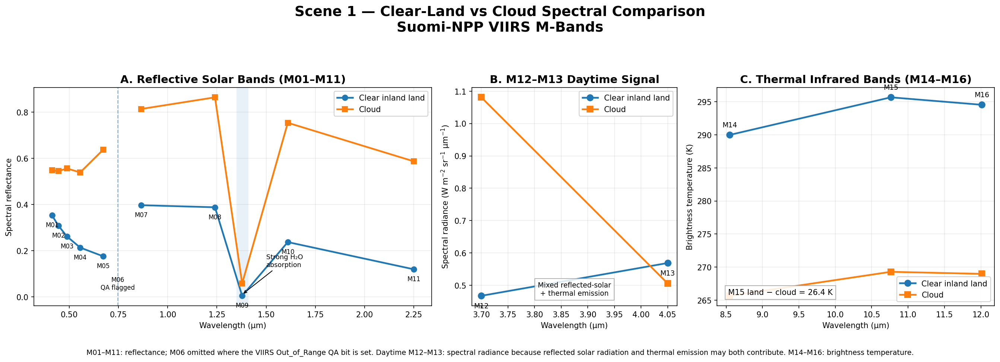

In [ ]:
# CODE CELL 18 — PART (D) LAND/CLOUD SPECTRAL COMPARISON
# ============================================================
# Scene 1
#
# Now I will compare the final clear-land and cloud pixels
# using the physically appropriate quantity for each VIIRS
# spectral region:
#
#   Panel A — M01–M11:
#             spectral reflectance
#
#   Panel B — M12–M13:
#             daytime spectral radiance
#
#   Panel C — M14–M16:
#             brightness temperature
#
# M06 remains omitted because the selected pixels are flagged
# Out_of_Range in the VIIRS QA field.
#
# Figure canvas size: 18 × 6.5 inches
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Scene and final selected pixels
# ------------------------------------------------------------

SPECTRAL_SCENE_ID = "scene1"
sd = scenes_data[SPECTRAL_SCENE_ID]

land_row, land_col = land_idx
cloud_row, cloud_col = cloud_idx


# ------------------------------------------------------------
# VIIRS M-band center wavelengths [µm]
# ------------------------------------------------------------

VIIRS_M_WAVELENGTH = {

    "M01": 0.412,
    "M02": 0.445,
    "M03": 0.488,
    "M04": 0.555,
    "M05": 0.672,
    "M06": 0.746,
    "M07": 0.865,
    "M08": 1.240,
    "M09": 1.378,
    "M10": 1.610,
    "M11": 2.250,

    "M12": 3.700,
    "M13": 4.050,

    "M14": 8.550,
    "M15": 10.763,
    "M16": 12.013
}


# ============================================================
# PANEL A DATA — REFLECTIVE SOLAR BANDS
# ============================================================

reflective_bands = [
    "M01", "M02", "M03", "M04",
    "M05", "M06", "M07", "M08",
    "M09", "M10", "M11"
]


reflective_wavelengths = np.array([
    VIIRS_M_WAVELENGTH[b]
    for b in reflective_bands
])


# ------------------------------------------------------------
# land_refl and cloud_refl MUST already come from the
# preceding QA-masking cell.
# ------------------------------------------------------------

if (
    "land_refl" not in globals()
    or
    "cloud_refl" not in globals()
):

    raise RuntimeError(
        "Run the QA-masked reflective-spectra cell first."
    )


m06_pos = reflective_bands.index(
    "M06"
)


if not (
    np.isnan(land_refl[m06_pos])
    and
    np.isnan(cloud_refl[m06_pos])
):

    raise RuntimeError(
        "M06 is not masked. "
        "Re-run the QA-masked spectra cell first."
    )


print(
    "✓ Using QA-masked M01–M11 spectra."
)

print(
    "✓ M06 is excluded for both selected pixels."
)


# ============================================================
# HELPER
# ============================================================

def pixel_value(
    band,
    variable,
    idx
):

    i, j = idx

    value = sd["bands"][band][variable][i, j]

    if np.ma.is_masked(value):
        return np.nan

    return float(value)


# ============================================================
# PANEL B DATA — M12–M13 DAYTIME RADIANCE
# ============================================================

mixed_bands = [
    "M12",
    "M13"
]


mixed_wavelengths = np.array([
    VIIRS_M_WAVELENGTH[b]
    for b in mixed_bands
])


land_mixed_rad = np.array([
    pixel_value(
        b,
        "radiance",
        land_idx
    )
    for b in mixed_bands
])


cloud_mixed_rad = np.array([
    pixel_value(
        b,
        "radiance",
        cloud_idx
    )
    for b in mixed_bands
])


# ============================================================
# PANEL C DATA — M14–M16 BRIGHTNESS TEMPERATURE
# ============================================================

thermal_bands = [
    "M14",
    "M15",
    "M16"
]


thermal_wavelengths = np.array([
    VIIRS_M_WAVELENGTH[b]
    for b in thermal_bands
])


land_bt = np.array([
    pixel_value(
        b,
        "bt",
        land_idx
    )
    for b in thermal_bands
])


cloud_bt = np.array([
    pixel_value(
        b,
        "bt",
        cloud_idx
    )
    for b in thermal_bands
])


# ============================================================
# PRINT DIAGNOSTICS
# ============================================================

print(
    "\nScene 1 spectral comparison"
)

print(
    "=" * 65
)


print(
    f"Clear land : "
    f"row={land_row}, col={land_col}, "
    f"lat={sd['lat'][land_row, land_col]:.4f}, "
    f"lon={sd['lon'][land_row, land_col]:.4f}"
)


print(
    f"Cloud      : "
    f"row={cloud_row}, col={cloud_col}, "
    f"lat={sd['lat'][cloud_row, cloud_col]:.4f}, "
    f"lon={sd['lon'][cloud_row, cloud_col]:.4f}"
)


# ============================================================
# CREATE THREE-PANEL FIGURE
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6.5),
    gridspec_kw={
        "width_ratios": [
            1.65,
            0.85,
            1.15
        ]
    }
)

ax1, ax2, ax3 = axes


# ============================================================
# PANEL A — REFLECTIVE SOLAR BANDS
# ============================================================

ax1.plot(
    reflective_wavelengths,
    land_refl,
    marker="o",
    linewidth=2.2,
    markersize=7,
    label="Clear inland land"
)


ax1.plot(
    reflective_wavelengths,
    cloud_refl,
    marker="s",
    linewidth=2.2,
    markersize=7,
    label="Cloud"
)


# ------------------------------------------------------------
# Label valid land-band locations
# ------------------------------------------------------------

for x, y, band in zip(
    reflective_wavelengths,
    land_refl,
    reflective_bands
):

    if np.isfinite(y):

        ax1.annotate(
            band,
            (x, y),
            xytext=(0, -15),
            textcoords="offset points",
            ha="center",
            fontsize=8
        )


# ------------------------------------------------------------
# M06 QA indicator
# ------------------------------------------------------------

m06_wave = VIIRS_M_WAVELENGTH[
    "M06"
]

ax1.axvline(
    m06_wave,
    linestyle="--",
    linewidth=1.2,
    alpha=0.55
)


ax1.text(
    m06_wave,
    0.025,
    "M06\nQA flagged",
    ha="center",
    va="bottom",
    fontsize=8
)


# ------------------------------------------------------------
# M09 strong atmospheric H2O absorption
# ------------------------------------------------------------

ax1.axvspan(
    1.35,
    1.41,
    alpha=0.10
)


ax1.annotate(
    "Strong H₂O\nabsorption",
    xy=(
        1.378,
        0.01
    ),
    xytext=(
        1.50,
        0.13
    ),
    fontsize=8.5,
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1
    )
)


ax1.set_title(
    "A. Reflective Solar Bands (M01–M11)",
    fontsize=14,
    fontweight="bold"
)

ax1.set_xlabel(
    "Wavelength (µm)"
)

ax1.set_ylabel(
    "Spectral reflectance"
)

ax1.grid(
    True,
    alpha=0.25
)

ax1.legend(
    loc="best",
    framealpha=0.95
)


# ============================================================
# PANEL B — M12–M13 DAYTIME RADIANCE
# ============================================================

ax2.plot(
    mixed_wavelengths,
    land_mixed_rad,
    marker="o",
    linewidth=2.2,
    markersize=8,
    label="Clear inland land"
)


ax2.plot(
    mixed_wavelengths,
    cloud_mixed_rad,
    marker="s",
    linewidth=2.2,
    markersize=8,
    label="Cloud"
)


for x, y, band in zip(
    mixed_wavelengths,
    land_mixed_rad,
    mixed_bands
):

    if np.isfinite(y):

        ax2.annotate(
            band,
            (x, y),
            xytext=(0, -16),
            textcoords="offset points",
            fontsize=9,
            ha="center"
        )


ax2.set_title(
    "B. M12–M13 Daytime Signal",
    fontsize=14,
    fontweight="bold"
)

ax2.set_xlabel(
    "Wavelength (µm)"
)

# Clean scientific unit formatting
ax2.set_ylabel(
    r"Spectral radiance "
    r"(W m$^{-2}$ sr$^{-1}$ µm$^{-1}$)"
)

ax2.grid(
    True,
    alpha=0.25
)

ax2.legend(
    loc="best",
    framealpha=0.95
)


ax2.text(
    0.5,
    0.04,
    "Mixed reflected-solar\n+ thermal emission",
    transform=ax2.transAxes,
    ha="center",
    va="bottom",
    fontsize=9,
    bbox=dict(
        facecolor="white",
        alpha=0.85,
        edgecolor="0.65",
        pad=4
    )
)


# ============================================================
# PANEL C — THERMAL BRIGHTNESS TEMPERATURE
# ============================================================

ax3.plot(
    thermal_wavelengths,
    land_bt,
    marker="o",
    linewidth=2.2,
    markersize=8,
    label="Clear inland land"
)


ax3.plot(
    thermal_wavelengths,
    cloud_bt,
    marker="s",
    linewidth=2.2,
    markersize=8,
    label="Cloud"
)


for x, y, band in zip(
    thermal_wavelengths,
    land_bt,
    thermal_bands
):

    if np.isfinite(y):

        ax3.annotate(
            band,
            (x, y),
            xytext=(0, 10),
            textcoords="offset points",
            ha="center",
            fontsize=9
        )


ax3.set_title(
    "C. Thermal Infrared Bands (M14–M16)",
    fontsize=14,
    fontweight="bold"
)

ax3.set_xlabel(
    "Wavelength (µm)"
)

ax3.set_ylabel(
    "Brightness temperature (K)"
)

ax3.grid(
    True,
    alpha=0.25
)

ax3.legend(
    loc="best",
    framealpha=0.95
)


# ------------------------------------------------------------
# M15 land–cloud thermal contrast
# ------------------------------------------------------------

if (
    np.isfinite(land_bt[1])
    and
    np.isfinite(cloud_bt[1])
):

    delta_t = (
        land_bt[1]
        -
        cloud_bt[1]
    )

    ax3.text(
        0.04,
        0.05,
        f"M15 land − cloud = {delta_t:.1f} K",
        transform=ax3.transAxes,
        fontsize=10,
        bbox=dict(
            facecolor="white",
            alpha=0.88,
            edgecolor="0.65",
            pad=4
        )
    )


# ============================================================
# MAIN TITLE
# ============================================================

fig.suptitle(
    "Scene 1 — Clear-Land vs Cloud Spectral Comparison\n"
    "Suomi-NPP VIIRS M-Bands",
    fontsize=18,
    fontweight="bold",
    y=0.985
)


# ============================================================
# FOOTNOTE
# ============================================================

fig.text(
    0.5,
    0.018,
    "M01–M11: reflectance; M06 omitted where the VIIRS "
    "Out_of_Range QA bit is set. "
    "Daytime M12–M13: spectral radiance because reflected "
    "solar radiation and thermal emission may both contribute. "
    "M14–M16: brightness temperature.",
    ha="center",
    va="bottom",
    fontsize=9.2
)


# ============================================================
# LAYOUT
# ============================================================

plt.tight_layout(
    rect=[
        0,
        0.07,
        1,
        0.92
    ]
)


# ============================================================
# SAVE AND DISPLAY
# ============================================================

savefig700(
    fig,
    "scene1_land_cloud_spectral_comparison_700dpi.png"
)

plt.show()
plt.close(fig)

**Code Cell 19 — Part (e) M01–M16 radiance comparison**

# Part (e) — M01–M16 radiance comparison

**Now I will place all 16 VIIRS M-bands on a common radiance basis for the same clear-land and cloud pixels.** To make all band names readable, the x-axis uses equal categorical spacing by band, while the actual center wavelength is printed below each label. Therefore, horizontal distance between adjacent markers is for readability and does not represent equal wavelength intervals.

The y-axis is logarithmic because radiance spans orders of magnitude across the visible, shortwave-infrared, and thermal regions. M06 remains omitted because the selected measurements are QA-flagged.

Figure canvas: **13.5 × 7.2 inches**.


Clear inland land: M06 radiance masked (quality flag=2, Out_of_Range)
Cloud: M06 radiance masked (quality flag=2, Out_of_Range)

M06 after QA screening:
  Clear land : nan
  Cloud      : nan
✓ M06 is correctly excluded.

Scene 1 — M01–M16 radiance
M01   0.415 µm   Land=161.9594019111246   Cloud=250.6671041753143
M02   0.445 µm   Land=153.50953190214932   Cloud=270.75343082658947
M03   0.490 µm   Land=140.21138879284263   Cloud=296.78861336037517
M04   0.555 µm   Land=106.90276751294732   Cloud=268.88226656243205
M05   0.673 µm   Land=71.98723202757537   Cloud=260.3110574949533
M06   0.746 µm   Land=nan   Cloud=nan
M07   0.865 µm   Land=102.43147849291563   Cloud=209.04456305131316
M08   1.240 µm   Land=47.386789286043495   Cloud=105.07934525306337
M09   1.378 µm   Land=0.4248172522056848   Cloud=5.558211064198986
M10   1.610 µm   Land=15.57069119811058   Cloud=49.281419542618096
M11   2.250 µm   Land=2.398042071639793   Cloud=11.743400843377458
M12   3.700 µm   Land=0.4675122541957535 

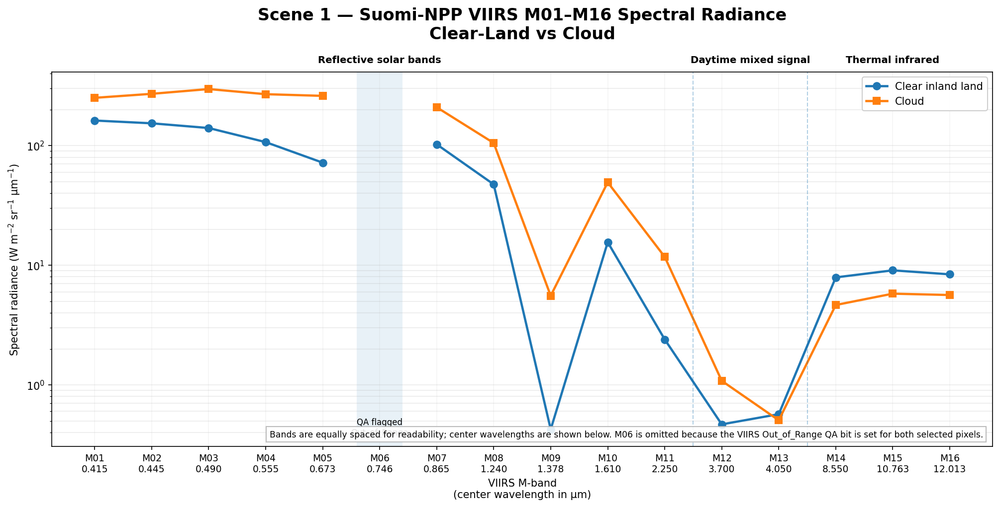

In [ ]:
# CODE CELL 19 — PART (E) M01–M16 RADIANCE COMPARISON
# ============================================================
# PART (e) — ALL VIIRS M-BANDS AS SPECTRAL RADIANCE
# FINAL PRESENTATION VERSION
#
# Scene 1: Clear-Land vs Cloud
#
# All M01–M16 bands are plotted as spectral radiance.
# Bands are equally spaced on the x-axis for readability;
# their actual center wavelengths are displayed below.
#
# M06 is omitted where the VIIRS Out_of_Range QA bit is set.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Scene
# ------------------------------------------------------------

SPECTRAL_SCENE_ID = "scene1"

sd = scenes_data[SPECTRAL_SCENE_ID]

rad_path = scene_files[
    SPECTRAL_SCENE_ID
]["radiance_path"]


# ------------------------------------------------------------
# All VIIRS M-bands
# ------------------------------------------------------------

all_m_bands = [
    "M01", "M02", "M03", "M04",
    "M05", "M06", "M07", "M08",
    "M09", "M10", "M11", "M12",
    "M13", "M14", "M15", "M16"
]


all_m_wavelengths = np.array([
    BAND_CENTERS_UM[b]
    for b in all_m_bands
], dtype=float)


# ============================================================
# QA-SCREENED RADIANCE EXTRACTION
# ============================================================

def get_radiance_spectrum(
    d,
    idx,
    pixel_name
):

    i, j = idx

    values = []

    for band in all_m_bands:

        value = d["bands"][band]["radiance"][i, j]

        # Convert masked native values to NaN
        if np.ma.is_masked(value):
            value = np.nan
        else:
            value = float(value)


        # ----------------------------------------------------
        # M06 QA SCREENING
        # ----------------------------------------------------

        if band == "M06":

            qflag, _ = read_pixel_quality(
                rad_path,
                "M06",
                idx
            )

            if (
                qflag is not None
                and
                (qflag & M06_OUT_OF_RANGE) != 0
            ):

                value = np.nan

                print(
                    f"{pixel_name}: M06 radiance masked "
                    f"(quality flag={qflag}, Out_of_Range)"
                )


        values.append(value)


    return np.array(
        values,
        dtype=float
    )


# ============================================================
# EXTRACT LAND AND CLOUD SPECTRA
# ============================================================

land_rad = get_radiance_spectrum(
    sd,
    land_idx,
    "Clear inland land"
)

cloud_rad = get_radiance_spectrum(
    sd,
    cloud_idx,
    "Cloud"
)


# ============================================================
# VERIFY M06 MASK
# ============================================================

m06_pos = all_m_bands.index("M06")

print("\nM06 after QA screening:")

print(
    f"  Clear land : {land_rad[m06_pos]}"
)

print(
    f"  Cloud      : {cloud_rad[m06_pos]}"
)


if not (
    np.isnan(land_rad[m06_pos])
    and
    np.isnan(cloud_rad[m06_pos])
):

    raise RuntimeError(
        "M06 should be QA-masked."
    )


print("✓ M06 is correctly excluded.")


# ============================================================
# PRINT RADIANCE VALUES
# ============================================================

print("\nScene 1 — M01–M16 radiance")
print("=" * 75)


for k, band in enumerate(all_m_bands):

    print(
        f"{band:>3s}  "
        f"{all_m_wavelengths[k]:6.3f} µm   "
        f"Land={land_rad[k]}   "
        f"Cloud={cloud_rad[k]}"
    )


# ============================================================
# RADIANCE UNITS
# ============================================================

radiance_units = sd["bands"]["M03"].get(
    "radiance_units",
    ""
)

print(
    "\nRadiance units from VIIRS metadata:",
    radiance_units
)


radiance_ylabel = (
    r"Spectral radiance "
    r"(W m$^{-2}$ sr$^{-1}$ µm$^{-1}$)"
)


# ============================================================
# CREATE FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(13.5, 7.2)
)


# Equal x positions for individual VIIRS bands
x = np.arange(
    len(all_m_bands)
)


# ------------------------------------------------------------
# Clear-land spectrum
# ------------------------------------------------------------

ax.plot(
    x,
    land_rad,
    marker="o",
    markersize=7,
    linewidth=2.2,
    label="Clear inland land"
)


# ------------------------------------------------------------
# Cloud spectrum
# ------------------------------------------------------------

ax.plot(
    x,
    cloud_rad,
    marker="s",
    markersize=7,
    linewidth=2.2,
    label="Cloud"
)


# ============================================================
# LOG RADIANCE AXIS
# ============================================================

ax.set_yscale(
    "log"
)


# ============================================================
# X-AXIS LABELS
# Band name + actual center wavelength
# ============================================================

tick_labels = [
    f"{band}\n{wave:.3f}"
    for band, wave in zip(
        all_m_bands,
        all_m_wavelengths
    )
]


ax.set_xticks(
    x
)

ax.set_xticklabels(
    tick_labels,
    fontsize=9
)


# ============================================================
# M06 QA INDICATION
# ============================================================

ax.axvspan(
    m06_pos - 0.40,
    m06_pos + 0.40,
    alpha=0.10
)


ax.text(
    m06_pos,
    0.025,
    "QA flagged\nOut_of_Range",
    transform=ax.get_xaxis_transform(),
    ha="center",
    va="bottom",
    fontsize=8
)


# ============================================================
# SPECTRAL-REGION SEPARATORS
# ============================================================

# Between M11 and M12
ax.axvline(
    10.5,
    linestyle="--",
    linewidth=1,
    alpha=0.35
)

# Between M13 and M14
ax.axvline(
    12.5,
    linestyle="--",
    linewidth=1,
    alpha=0.35
)


# ------------------------------------------------------------
# Spectral-region labels
# ------------------------------------------------------------

ax.text(
    5.0,
    1.025,
    "Reflective solar bands",
    transform=ax.get_xaxis_transform(),
    ha="center",
    fontsize=9.5,
    fontweight="bold"
)


ax.text(
    11.5,
    1.025,
    "Daytime mixed signal",
    transform=ax.get_xaxis_transform(),
    ha="center",
    fontsize=9.5,
    fontweight="bold"
)


ax.text(
    14.0,
    1.025,
    "Thermal infrared",
    transform=ax.get_xaxis_transform(),
    ha="center",
    fontsize=9.5,
    fontweight="bold"
)


# ============================================================
# AXIS LABELS
# ============================================================

ax.set_xlabel(
    "VIIRS M-band\n"
    "(center wavelength in µm)"
)


ax.set_ylabel(
    radiance_ylabel
)


# ============================================================
# TITLE
# ============================================================

ax.set_title(
    "Scene 1 — Suomi-NPP VIIRS M01–M16 Spectral Radiance\n"
    "Clear-Land vs Cloud",
    fontsize=16,
    fontweight="bold",
    pad=32
)


# ============================================================
# GRID + LEGEND
# ============================================================

ax.grid(
    True,
    axis="y",
    which="both",
    alpha=0.25
)

ax.grid(
    True,
    axis="x",
    alpha=0.12
)


ax.legend(
    loc="upper right",
    framealpha=0.95
)


# ============================================================
# SCIENTIFIC NOTE
# ============================================================

ax.text(
    0.99,
    0.02,
    "Bands are equally spaced for readability; center wavelengths "
    "are shown below. M06 is omitted because the VIIRS "
    "Out_of_Range QA bit is set for both selected pixels.",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=8.3,
    bbox=dict(
        facecolor="white",
        alpha=0.88,
        edgecolor="0.7",
        pad=3
    )
)


# ============================================================
# LAYOUT
# ============================================================

fig.tight_layout(
    rect=[
        0,
        0,
        1,
        0.96
    ]
)


# ============================================================
# SAVE
# ============================================================

savefig700(
    fig,
    "scene1_land_cloud_M01_M16_radiance_700dpi.png"
)


# ============================================================
# DISPLAY
# ============================================================

plt.show()

plt.close(fig)

**Code Cell 20 — Export Scene 1 spectral values**

## 9. Export the Scene 1 spectral values

**Now I will write the land/cloud spectral measurements to a CSV for documentation and reproducibility.** The table contains 2 pixels × 16 bands = **32 rows**, including row/column location, latitude/longitude, wavelength, reflectance where applicable, brightness temperature where applicable, radiance, and M06 QA fields.

For consistency with the figures, M06 reflectance and radiance are stored as `NaN` where the `Out_of_Range` QA bit is set.


In [ ]:
# CODE CELL 20 — EXPORT SCENE 1 SPECTRAL VALUES
# ============================================================
# EXPORT SCENE 1 LAND/CLOUD SPECTRAL VALUES TO CSV
#
# M06 reflectance and radiance are stored as NaN when
# the VIIRS Out_of_Range QA bit is set.
# ============================================================

rows = []


for name, idx in [
    ("clear_inland_land", land_idx),
    ("cloud", cloud_idx)
]:

    i, j = idx


    for band in ALL_M_BANDS:

        # ----------------------------------------------------
        # Base values
        # ----------------------------------------------------

        radiance_value = sd["bands"][band]["radiance"][i, j]


        if np.ma.is_masked(radiance_value):
            radiance_value = np.nan
        else:
            radiance_value = float(radiance_value)


        # Reflectance only exists for reflective solar bands
        if band in RSB_BANDS:

            reflectance_value = (
                sd["bands"][band]["reflectance"][i, j]
            )

            if np.ma.is_masked(reflectance_value):
                reflectance_value = np.nan
            else:
                reflectance_value = float(
                    reflectance_value
                )

        else:

            reflectance_value = np.nan


        # Brightness temperature only for thermal emissive bands
        if band in TEB_BANDS:

            bt_value = (
                sd["bands"][band]["bt"][i, j]
            )

            if np.ma.is_masked(bt_value):
                bt_value = np.nan
            else:
                bt_value = float(
                    bt_value
                )

        else:

            bt_value = np.nan


        # ----------------------------------------------------
        # QA information
        # ----------------------------------------------------

        quality_flag = np.nan
        uncertainty_index = np.nan
        out_of_range = False


        if band == "M06":

            qflag, uncert = read_pixel_quality(
                rad_path,
                "M06",
                idx
            )

            quality_flag = qflag
            uncertainty_index = uncert

            out_of_range = (
                qflag is not None
                and
                (qflag & M06_OUT_OF_RANGE) != 0
            )


            # -----------------------------------------------
            # Mask scientifically invalid M06 values
            # -----------------------------------------------

            if out_of_range:

                reflectance_value = np.nan
                radiance_value = np.nan


        # ----------------------------------------------------
        # Add row
        # ----------------------------------------------------

        rows.append({

            "pixel_type":
                name,

            "row":
                i,

            "column":
                j,

            "latitude":
                float(sd["lat"][i, j]),

            "longitude":
                float(sd["lon"][i, j]),

            "band":
                band,

            "wavelength_um":
                BAND_CENTERS_UM[band],

            "reflectance":
                reflectance_value,

            "brightness_temperature_K":
                bt_value,

            "radiance":
                radiance_value,

            "quality_flag_raw":
                quality_flag,

            "out_of_range":
                out_of_range,

            "uncertainty_index":
                uncertainty_index
        })


# ============================================================
# CREATE DATAFRAME
# ============================================================

spectral_df = pd.DataFrame(
    rows
)


# ============================================================
# DISPLAY
# ============================================================

display(
    spectral_df
)


# ============================================================
# SAVE CSV
# ============================================================

spectral_csv_path = (
    OUTPUT_DIR /
    "scene1_land_cloud_spectral_values.csv"
)


spectral_df.to_csv(
    spectral_csv_path,
    index=False
)


print(
    f"✓ Spectral-value CSV saved: "
    f"{spectral_csv_path}"
)

print(
    f"✓ Rows written: "
    f"{len(spectral_df)}"
)

print(
    "✓ M06 reflectance/radiance are NaN where "
    "the Out_of_Range QA bit is set."
)

,pixel_type,row,column,latitude,longitude,band,wavelength_um,reflectance,brightness_temperature_K,radiance,quality_flag_raw,out_of_range,uncertainty_index
0,clear_inland_land,2994,231,39.674736,-75.929955,M01,0.415,0.352507,NaN,161.959402,NaN,False,NaN
1,clear_inland_land,2994,231,39.674736,-75.929955,M02,0.445,0.307354,NaN,153.509532,NaN,False,NaN
2,clear_inland_land,2994,231,39.674736,-75.929955,M03,0.490,0.261323,NaN,140.211389,NaN,False,NaN
3,clear_inland_land,2994,231,39.674736,-75.929955,M04,0.555,0.213216,NaN,106.902768,NaN,False,NaN
4,clear_inland_land,2994,231,39.674736,-75.929955,M05,0.673,0.175423,NaN,71.987232,NaN,False,NaN
5,clear_inland_land,2994,231,39.674736,-75.929955,M06,0.746,NaN,NaN,NaN,2.0,True,0.0
6,clear_inland_land,2994,231,39.674736,-75.929955,M07,0.865,0.396761,NaN,102.431478,NaN,False,NaN
7,clear_inland_land,2994,231,39.674736,-75.929955,M08,1.240,0.387763,NaN,47.386789,NaN,False,NaN
8,clear_inland_land,2994,231,39.674736,-75.929955,M09,1.378,0.004407,NaN,0.424817,NaN,False,NaN
9,clear_inland_land,2994,231,39.674736,-75.929955,M10,1.610,0.237005,NaN,15.570691,NaN,False,NaN


✓ Spectral-value CSV saved: /content/Mirza_VIIRS_Plots_outputs/outputs/scene1_land_cloud_spectral_values.csv
✓ Rows written: 32
✓ M06 reflectance/radiance are NaN where the Out_of_Range QA bit is set.


**Code Cell 21 — Final output audit**

# 10. Final output audit

**Now I will verify that every required figure, table, binary file, and JSON sidecar exists before packaging the submission.** I also report the projected AOI coverage retained for each scene.

The expected final figure set contains **8 figures**: four scene images, two selected-pixel verification figures, one mixed-quantity spectral comparison, and one all-band radiance comparison.


In [ ]:
# CODE CELL 21 — FINAL OUTPUT AUDIT
# ============================================================
# 10. FINAL OUTPUT AUDIT
# ============================================================

from pathlib import Path
import numpy as np


# ------------------------------------------------------------
# Expected final outputs
# ------------------------------------------------------------

expected = [

    # --------------------------------------------------------
    # Four required true-color scene figures
    # --------------------------------------------------------

    FIG_DIR /
    "scene1_unprojected_true_color_700dpi.png",

    FIG_DIR /
    "scene1_projected_true_color_700dpi.png",

    FIG_DIR /
    "scene2_unprojected_true_color_700dpi.png",

    FIG_DIR /
    "scene2_projected_true_color_700dpi.png",


    # --------------------------------------------------------
    # Scene 1 selected-pixel figures
    # --------------------------------------------------------

    FIG_DIR /
    "scene1_selected_pixels_projected_700dpi.png",

    FIG_DIR /
    "scene1_selected_pixels_native_swath_700dpi.png",


    # --------------------------------------------------------
    # Scene 1 spectral figures
    # --------------------------------------------------------

    FIG_DIR /
    "scene1_land_cloud_spectral_comparison_700dpi.png",

    FIG_DIR /
    "scene1_land_cloud_M01_M16_radiance_700dpi.png",


    # --------------------------------------------------------
    # Metadata / tabular outputs
    # --------------------------------------------------------

    OUTPUT_DIR /
    "scene_metadata.csv",

    OUTPUT_DIR /
    "scene_date_time_and_features.csv",

    OUTPUT_DIR /
    "scene1_land_cloud_spectral_values.csv",

    OUTPUT_DIR /
    "binary_file_manifest.csv",
]


# ============================================================
# CHECK EXPECTED FILES
# ============================================================

print("=" * 75)
print("FINAL OUTPUT AUDIT")
print("=" * 75)

missing = []

for p in expected:

    exists = p.exists()

    print(
        ("✓" if exists else "✗"),
        p
    )

    if not exists:
        missing.append(p)


# ============================================================
# CHECK BINARY FILES
# ============================================================

binary_files = sorted(
    BINARY_DIR.glob("*.bin")
)

json_sidecars = sorted(
    BINARY_DIR.glob("*.bin.json")
)


print("\n" + "=" * 75)
print("BINARY OUTPUTS")
print("=" * 75)

print(
    "Binary radiance files:",
    len(binary_files)
)

print(
    "JSON sidecars:",
    len(json_sidecars)
)


# Expected:
# 2 scenes × 5 required bands = 10 binary files

if len(binary_files) == 10:

    print(
        "✓ Correct number of binary radiance files."
    )

else:

    print(
        f"⚠ Expected 10 binary files, "
        f"but found {len(binary_files)}."
    )


if len(json_sidecars) == 10:

    print(
        "✓ Correct number of JSON sidecars."
    )

else:

    print(
        f"⚠ Expected 10 JSON sidecars, "
        f"but found {len(json_sidecars)}."
    )


# ============================================================
# CHECK PROJECTION COVERAGE
# ============================================================

print("\n" + "=" * 75)
print("PROJECTED AOI COVERAGE")
print("=" * 75)


for scene in SCENES:

    sid = scene["id"]

    cov = scenes_data[sid].get(
        "projected_coverage_pct",
        np.nan
    )

    if np.isfinite(cov):

        print(
            f"{sid}: "
            f"{cov:.1f}% valid AOI coverage"
        )

    else:

        print(
            f"{sid}: coverage unavailable"
        )


# ============================================================
# OUTPUT LOCATION
# ============================================================

print("\n" + "=" * 75)
print("OUTPUT DIRECTORY")
print("=" * 75)

print(
    OUTPUT_DIR
)


# ============================================================
# FINAL STATUS
# ============================================================

print("\n" + "=" * 75)
print("FINAL STATUS")
print("=" * 75)


if len(missing) == 0:

    print(
        "✓ All expected final outputs are present."
    )

else:

    print(
        f"⚠ {len(missing)} expected output(s) are missing:"
    )

    for p in missing:

        print(
            "  -",
            p
        )


if (
    len(binary_files) == 10
    and
    len(json_sidecars) == 10
):

    print(
        "✓ Binary export is complete."
    )


print(
    "\nAudit complete."
)


FINAL OUTPUT AUDIT
✓ /content/Mirza_VIIRS_Plots_outputs/outputs/figures/scene1_unprojected_true_color_700dpi.png
✓ /content/Mirza_VIIRS_Plots_outputs/outputs/figures/scene1_projected_true_color_700dpi.png
✓ /content/Mirza_VIIRS_Plots_outputs/outputs/figures/scene2_unprojected_true_color_700dpi.png
✓ /content/Mirza_VIIRS_Plots_outputs/outputs/figures/scene2_projected_true_color_700dpi.png
✓ /content/Mirza_VIIRS_Plots_outputs/outputs/figures/scene1_selected_pixels_projected_700dpi.png
✓ /content/Mirza_VIIRS_Plots_outputs/outputs/figures/scene1_selected_pixels_native_swath_700dpi.png
✓ /content/Mirza_VIIRS_Plots_outputs/outputs/figures/scene1_land_cloud_spectral_comparison_700dpi.png
✓ /content/Mirza_VIIRS_Plots_outputs/outputs/figures/scene1_land_cloud_M01_M16_radiance_700dpi.png
✓ /content/Mirza_VIIRS_Plots_outputs/outputs/scene_metadata.csv
✗ /content/Mirza_VIIRS_Plots_outputs/outputs/scene_date_time_and_features.csv
✓ /content/Mirza_VIIRS_Plots_outputs/outputs/scene1_land_cloud_spectr

**Code Cell 22 — Final output packaging**

## 11. Final pre-submission packaging

**Now I will package the verified outputs into a clean submission directory and ZIP archive.** I will copy the final files using professional sequential names, preserve the 10 binary radiance files and their JSON sidecars, include the four CSV tables, and write a README describing the package.

Before running this cell, the audit above should show all expected outputs with `✓`.


In [ ]:
# CODE CELL 22 — FINAL OUTPUT PACKAGING
# ============================================================
# FINAL OUTPUT PACKAGING AND AUTO-DOWNLOAD
# ============================================================

import os
import shutil
import zipfile
from pathlib import Path

# ------------------------------------------------------------
# 1. Create a clean submission directory
# ------------------------------------------------------------

PACKAGE_ROOT = Path("/content/Mirza_VIIRS_Plots_Submission")
FIG_PACKAGE = PACKAGE_ROOT / "Figures"
BIN_PACKAGE = PACKAGE_ROOT / "Binary_Radiance_Files"
TABLE_PACKAGE = PACKAGE_ROOT / "Tables_and_Metadata"

for folder in [FIG_PACKAGE, BIN_PACKAGE, TABLE_PACKAGE]:
    folder.mkdir(parents=True, exist_ok=True)

# Remove files from a previous packaging run so the package
# always reflects the current notebook outputs.
for folder in [FIG_PACKAGE, BIN_PACKAGE, TABLE_PACKAGE]:
    for p in folder.iterdir():
        if p.is_file():
            p.unlink()


# ------------------------------------------------------------
# 2. Package the eight final figures
# ------------------------------------------------------------

figure_files = [
    (
        FIG_DIR / "scene1_unprojected_true_color_700dpi.png",
        "Fig01_Scene1_VIIRS_TrueColor_Native.png"
    ),
    (
        FIG_DIR / "scene1_projected_true_color_700dpi.png",
        "Fig02_Scene1_VIIRS_TrueColor_Projected.png"
    ),
    (
        FIG_DIR / "scene2_unprojected_true_color_700dpi.png",
        "Fig03_Scene2_VIIRS_TrueColor_Native.png"
    ),
    (
        FIG_DIR / "scene2_projected_true_color_700dpi.png",
        "Fig04_Scene2_VIIRS_TrueColor_Projected.png"
    ),
    (
        FIG_DIR / "scene1_selected_pixels_projected_700dpi.png",
        "Fig05_Scene1_Selected_Pixels_Projected.png"
    ),
    (
        FIG_DIR / "scene1_selected_pixels_native_swath_700dpi.png",
        "Fig06_Scene1_Selected_Pixels_Native.png"
    ),
    (
        FIG_DIR / "scene1_land_cloud_spectral_comparison_700dpi.png",
        "Fig07_Scene1_Land_Cloud_Spectral_Comparison.png"
    ),
    (
        FIG_DIR / "scene1_land_cloud_M01_M16_radiance_700dpi.png",
        "Fig08_Scene1_Land_Cloud_M01_M16_Radiance.png"
    ),
]

copied_figures = []

for src, new_name in figure_files:
    if src.exists():
        dst = FIG_PACKAGE / new_name
        shutil.copy2(src, dst)
        copied_figures.append(dst)
        print(f"✓ Figure copied: {new_name}")
    else:
        print(f"⚠ Missing figure: {src.name}")


# ------------------------------------------------------------
# 3. Package the ten required binary radiance files
# ------------------------------------------------------------

binary_order = [
    ("scene1_blue_M03_radiance_float32.bin", "Band01_Scene1_Blue_M03_Radiance.bin"),
    ("scene1_green_M04_radiance_float32.bin", "Band02_Scene1_Green_M04_Radiance.bin"),
    ("scene1_red_M05_radiance_float32.bin", "Band03_Scene1_Red_M05_Radiance.bin"),
    ("scene1_thermal_11um_M15_radiance_float32.bin", "Band04_Scene1_Thermal_M15_11um_Radiance.bin"),
    ("scene1_thermal_12um_M16_radiance_float32.bin", "Band05_Scene1_Thermal_M16_12um_Radiance.bin"),
    ("scene2_blue_M03_radiance_float32.bin", "Band06_Scene2_Blue_M03_Radiance.bin"),
    ("scene2_green_M04_radiance_float32.bin", "Band07_Scene2_Green_M04_Radiance.bin"),
    ("scene2_red_M05_radiance_float32.bin", "Band08_Scene2_Red_M05_Radiance.bin"),
    ("scene2_thermal_11um_M15_radiance_float32.bin", "Band09_Scene2_Thermal_M15_11um_Radiance.bin"),
    ("scene2_thermal_12um_M16_radiance_float32.bin", "Band10_Scene2_Thermal_M16_12um_Radiance.bin"),
]

copied_binaries = []

for old_name, new_name in binary_order:
    src = BINARY_DIR / old_name

    if src.exists():
        dst = BIN_PACKAGE / new_name
        shutil.copy2(src, dst)
        copied_binaries.append(dst)
        print(f"✓ Binary copied: {new_name}")

        # Preserve the JSON metadata sidecar for the renamed binary.
        sidecar = Path(str(src) + ".json")
        if sidecar.exists():
            shutil.copy2(
                sidecar,
                BIN_PACKAGE / f"{new_name}.json"
            )
    else:
        print(f"⚠ Missing binary file: {old_name}")


# ------------------------------------------------------------
# 4. Package tables and metadata
# ------------------------------------------------------------

table_files = [
    (OUTPUT_DIR / "scene_metadata.csv", "Table01_Scene_Metadata.csv"),
    (OUTPUT_DIR / "scene_date_time_and_features.csv", "Table02_Scene_DateTime_and_Features.csv"),
    (OUTPUT_DIR / "binary_file_manifest.csv", "Table03_Binary_Radiance_Manifest.csv"),
    (OUTPUT_DIR / "scene1_land_cloud_spectral_values.csv", "Table04_Land_Cloud_Spectral_Values.csv"),
]

copied_tables = []

for src, new_name in table_files:
    if src.exists():
        dst = TABLE_PACKAGE / new_name
        shutil.copy2(src, dst)
        copied_tables.append(dst)
        print(f"✓ Table copied: {new_name}")
    else:
        print(f"⚠ Missing table: {src.name}")


# ------------------------------------------------------------
# 5. Write package README
# ------------------------------------------------------------

readme_text = """MIRZA_VIIRS_PLOTS — SUOMI-NPP VIIRS LEVEL-1B ANALYSIS
=====================================================

Case studies
------------
Scene 1: 7 June 2023 — Northeastern U.S. wildfire smoke
Scene 2: 28 September 2022 — Hurricane Ian over Florida

Native VIIRS M-band array size
------------------------------
3232 rows x 3200 columns = 10,342,400 samples per band.

Projected map grid spacing
--------------------------
0.0075 degrees x 0.0075 degrees.
This is the output resampling-grid spacing, not additional sensor resolution.

Figures
-------
Fig01  Scene 1 true color — native swath
Fig02  Scene 1 true color — projected geographic grid
Fig03  Scene 2 true color — native swath
Fig04  Scene 2 true color — projected geographic grid
Fig05  Scene 1 selected clear-land/cloud pixels — projected
Fig06  Scene 1 selected clear-land/cloud pixels — native swath
Fig07  Scene 1 land/cloud spectral comparison
Fig08  Scene 1 M01-M16 land/cloud radiance comparison

Binary_Radiance_Files
---------------------
Band01-Band05: Scene 1 M03, M04, M05, M15, M16 radiance
Band06-Band10: Scene 2 M03, M04, M05, M15, M16 radiance

Binary format:
float32, little-endian, C row-major, invalid values stored as NaN.

Each 3232 x 3200 float32 array is approximately 39.45 MiB.

Tables_and_Metadata
-------------------
Table01  Scene metadata
Table02  Scene date/time and feature descriptions
Table03  Binary-radiance manifest
Table04  Scene 1 land/cloud spectral values

QA note
-------
For the selected Scene 1 land and cloud pixels, M06 has the VIIRS
Out_of_Range QA bit set. M06 reflectance/radiance is therefore stored
as NaN in the spectral table and omitted from scientific interpretation.

Data source
-----------
NASA LAADS DAAC
Suomi-NPP VIIRS
VNP02MOD Level-1B observations
VNP03MOD geolocation

Figures are exported at 700 dpi.
"""

with open(PACKAGE_ROOT / "README.txt", "w", encoding="utf-8") as f:
    f.write(readme_text)


# ------------------------------------------------------------
# 6. Display the final package structure
# ------------------------------------------------------------

print("\n" + "=" * 72)
print("FINAL PACKAGE STRUCTURE")
print("=" * 72)

for root, dirs, files in os.walk(PACKAGE_ROOT):
    level = root.replace(str(PACKAGE_ROOT), "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{Path(root).name}/")

    subindent = "    " * (level + 1)
    for filename in sorted(files):
        print(f"{subindent}{filename}")


# ------------------------------------------------------------
# 7. Create ZIP archive
# ------------------------------------------------------------

ZIP_PATH = Path("/content/Mirza_VIIRS_Plots_Submission.zip")

if ZIP_PATH.exists():
    ZIP_PATH.unlink()

with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file_path in PACKAGE_ROOT.rglob("*"):
        if file_path.is_file():
            arcname = file_path.relative_to(PACKAGE_ROOT.parent)
            zipf.write(file_path, arcname)


# ------------------------------------------------------------
# 8. Report package status
# ------------------------------------------------------------

zip_size_mb = ZIP_PATH.stat().st_size / (1024**2)

print("\n" + "=" * 72)
print("ZIP CREATION COMPLETE")
print("=" * 72)
print(f"ZIP file: {ZIP_PATH.name}")
print(f"ZIP size: {zip_size_mb:.2f} MB")
print(f"Figures packaged: {len(copied_figures)} / 8")
print(f"Binary radiance files packaged: {len(copied_binaries)} / 10")
print(f"Tables packaged: {len(copied_tables)} / 4")


# ------------------------------------------------------------
# 9. Download automatically when running in Google Colab
# ------------------------------------------------------------

try:
    from google.colab import files

    print("\nStarting download...")
    files.download(str(ZIP_PATH))

except ImportError:
    print("\nNot running inside Google Colab.")
    print(f"ZIP is available at: {ZIP_PATH}")


## Final interpretation guide

**Code Cells 01–22 are complete above.** The notes below summarize how I will discuss the outputs in the written submission.


### Native swath figures
I use the native figures to discuss the original VIIRS scan-array geometry. Any remaining bow-tie/fill structure belongs to the sampling geometry rather than the map projection.

### Projected figures
I use the projected figures to discuss geographic location and morphology. Projection resamples the observations onto a **0.0075°** grid for mapping; it does not create new spatial information.

### Scene 1
The principal feature is widespread wildfire smoke/haze over the Mid-Atlantic and northeastern coastal region. I should describe only features clearly supported by the imagery.

### Scene 2
The principal feature is Hurricane Ian's extensive cloud shield and spiral circulation over Florida and adjacent waters on 28 September 2022.

### Clear land vs cloud
The selected cloud is brighter than the clear-land pixel across much of the solar-reflective spectrum and substantially colder in the longwave thermal bands. Daytime M12/M13 require caution because reflected sunlight can contribute at 3.7–4.05 µm.

### M06 QA decision
For both final Scene 1 reference pixels, the M06 quality flag has the `Out_of_Range` bit set. I therefore keep M06 in the documented band sequence but store/plot its reflectance and radiance as `NaN`. I do not interpret the anomalous raw M06 value as a physical absorption feature.

### M09
The low signal near M09 (~1.38 µm) is consistent with strong atmospheric water-vapor absorption and is treated separately from the M06 QA issue.

### Radiance-only figure
The Part (e) plot shows all M-bands on a common radiance basis. Bands are **equally spaced for readability**, and the actual center wavelength is printed beneath each band; the horizontal spacing is therefore categorical rather than proportional to wavelength.

### Scientific limitations
Brightness temperature is not necessarily true surface temperature. Reflectance depends on illumination, atmosphere, and viewing geometry. Projection changes the sampling grid. Pixel-level interpretation should always be supported by spatial context and product QA.
